In [1]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
ds1 = xr.open_dataset('/glade/work/netige/Data/VIKING/viking_obp_ssh_msc_residuals.nc')
viking_ds = xr.open_dataset("/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc")

In [3]:
with ProgressBar():

# --- inputs ---
    raw_obp = viking_ds["obp_rm_dt"]          # (time, lat, lon)
    msc_obp = ds1["viking_obp_MSC"]           # (month, lat, lon)
    res_obp = ds1["viking_obp_res"]           # (time, lat, lon)

# --- compute std maps ---
    std_raw = raw_obp.std(dim="time", skipna=True).compute()
    std_msc = msc_obp.std(dim="month", skipna=True).compute()
    std_res = res_obp.std(dim="time", skipna=True).compute()

# Use a common color scale across panels (optional but recommended)
    vmin = float(xr.concat([std_raw, std_msc, std_res], dim="z").min(skipna=True))
    vmax = float(xr.concat([std_raw, std_msc, std_res], dim="z").max(skipna=True))


### Coarsen data to 3-deg and re-do stds

In [3]:
import numpy as np
import xarray as xr
from typing import Optional, Sequence, Union

import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

def bin_average_ll_true2d(
    da: xr.DataArray,
    *,
    res: float = 1.0,
    lat_name: str = "lat",
    lon_name: str = "lon",
    prechunk=None,
    postchunk=None,
) -> xr.DataArray:

    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values
    lat_min, lat_max = float(np.nanmin(lat_vals)), float(np.nanmax(lat_vals))
    lon_min, lon_max = float(np.nanmin(lon_vals)), float(np.nanmax(lon_vals))

    def make_bins(vmin, vmax, step):
        start = np.floor(vmin / step) * step
        stop  = np.ceil (vmax / step) * step
        edges = np.arange(start, stop + step, step, dtype=float)
        labels = (edges[:-1] + edges[1:]) / 2.0
        return edges, labels

    lat_bins, lat_labels = make_bins(lat_min, lat_max, res)
    lon_bins, lon_labels = make_bins(lon_min, lon_max, res)
    nlon = len(lon_labels)

    if prechunk is not None:
        da = da.chunk(prechunk)
    elif "time" in da.dims:
        da = da.chunk({"time": -1})

    # 1D bin indices on each axis
    ilat = xr.DataArray(
        np.digitize(da[lat_name].values, lat_bins) - 1,
        dims=(lat_name,),
        coords={lat_name: da[lat_name]},
    )
    ilon = xr.DataArray(
        np.digitize(da[lon_name].values, lon_bins) - 1,
        dims=(lon_name,),
        coords={lon_name: da[lon_name]},
    )

    # broadcast to 2D bin indices
    ilat2d, ilon2d = xr.broadcast(ilat, ilon)

    valid = (
        (ilat2d >= 0) & (ilat2d < len(lat_labels)) &
        (ilon2d >= 0) & (ilon2d < len(lon_labels))
    )

    gid2d = (ilat2d * nlon + ilon2d).where(valid)

    # stack spatial dims -> points, drop invalid gid points
    da2 = da.assign_coords(gid=gid2d)
    s = da2.stack(points=(lat_name, lon_name))
    s = s.where(np.isfinite(s["gid"]), drop=True)

    # group mean across ALL points in each (ilat, ilon) bin (true 2D)
    out = s.groupby("gid").mean("points", skipna=True)

    # attach ilat/ilon as coords *along gid* (this is allowed)
    gid_vals = out["gid"].values.astype(np.int64)
    out = out.assign_coords(
        ilat=("gid", (gid_vals // nlon).astype(np.int64)),
        ilon=("gid", (gid_vals %  nlon).astype(np.int64)),
    )

    # pivot gid -> (ilat, ilon) -> (lat, lon)
    out2 = (
        out.set_index(gid=["ilat", "ilon"])
           .unstack("gid")
           .rename({"ilat": "lat", "ilon": "lon"})
    )

    # now safely assign actual coordinate values for the bin centers
    out2 = out2.assign_coords(
        lat=("lat", lat_labels),
        lon=("lon", lon_labels),
    )

    if postchunk is not None:
        out2 = out2.chunk(postchunk)

    return out2



def remove_seasonal_cycle(ds, time_dim="time", groupby="time.month"):
    """
    Remove the seasonal mean cycle from an xarray dataset.

    Parameters:
    ds (xr.Dataset or xr.DataArray): Input dataset or data array.
    time_dim (str): Name of the time dimension.
    groupby (str): Grouping method, default is 'time.month' (monthly climatology).

    Returns:
    xr.Dataset or xr.DataArray: Dataset or data array with the seasonal cycle removed.
    """
    climatology = ds.groupby(groupby).mean(dim=time_dim)
    return climatology, ds.groupby(groupby) - climatology

In [4]:
with ProgressBar():
    obp_3deg = bin_average_ll_true2d(
            viking_ds["obp_rm_dt"]  ,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

[########################################] | 100% Completed | 51.83 s


In [6]:
from dask.diagnostics import ProgressBar
import dask

# Rechunk to reduce task overhead
obp_3deg_rc = obp_3deg.chunk({"time": -1, "lat": 34, "lon": 40})  # single spatial chunk

# Or, if you prefer a couple chunks:
# obp_3deg_rc = obp_3deg.chunk({"time": -1, "lat": 17, "lon": 20})

msc, res = remove_seasonal_cycle(obp_3deg_rc)

# Persist (or compute) both together
with ProgressBar():
    viking_obp_MSC_3deg, viking_obp_res_3deg = dask.persist(msc, res)


[########################################] | 100% Completed | 327.44 ms


In [7]:
# --- inputs ---
raw_obp_3deg = obp_3deg          # (time, lat, lon)
msc_obp_3deg = viking_obp_MSC_3deg           # (month, lat, lon)
res_obp_3deg = viking_obp_res_3deg           # (time, lat, lon)

# --- compute std maps ---
with ProgressBar():
    std_raw_3deg = raw_obp_3deg.std(dim="time", skipna=True).compute()
    std_msc_3deg = msc_obp_3deg.std(dim="month", skipna=True).compute()
    std_res_3deg = res_obp_3deg.std(dim="time", skipna=True).compute()


[########################################] | 100% Completed | 122.62 ms
[########################################] | 100% Completed | 106.24 ms
[########################################] | 100% Completed | 108.00 ms


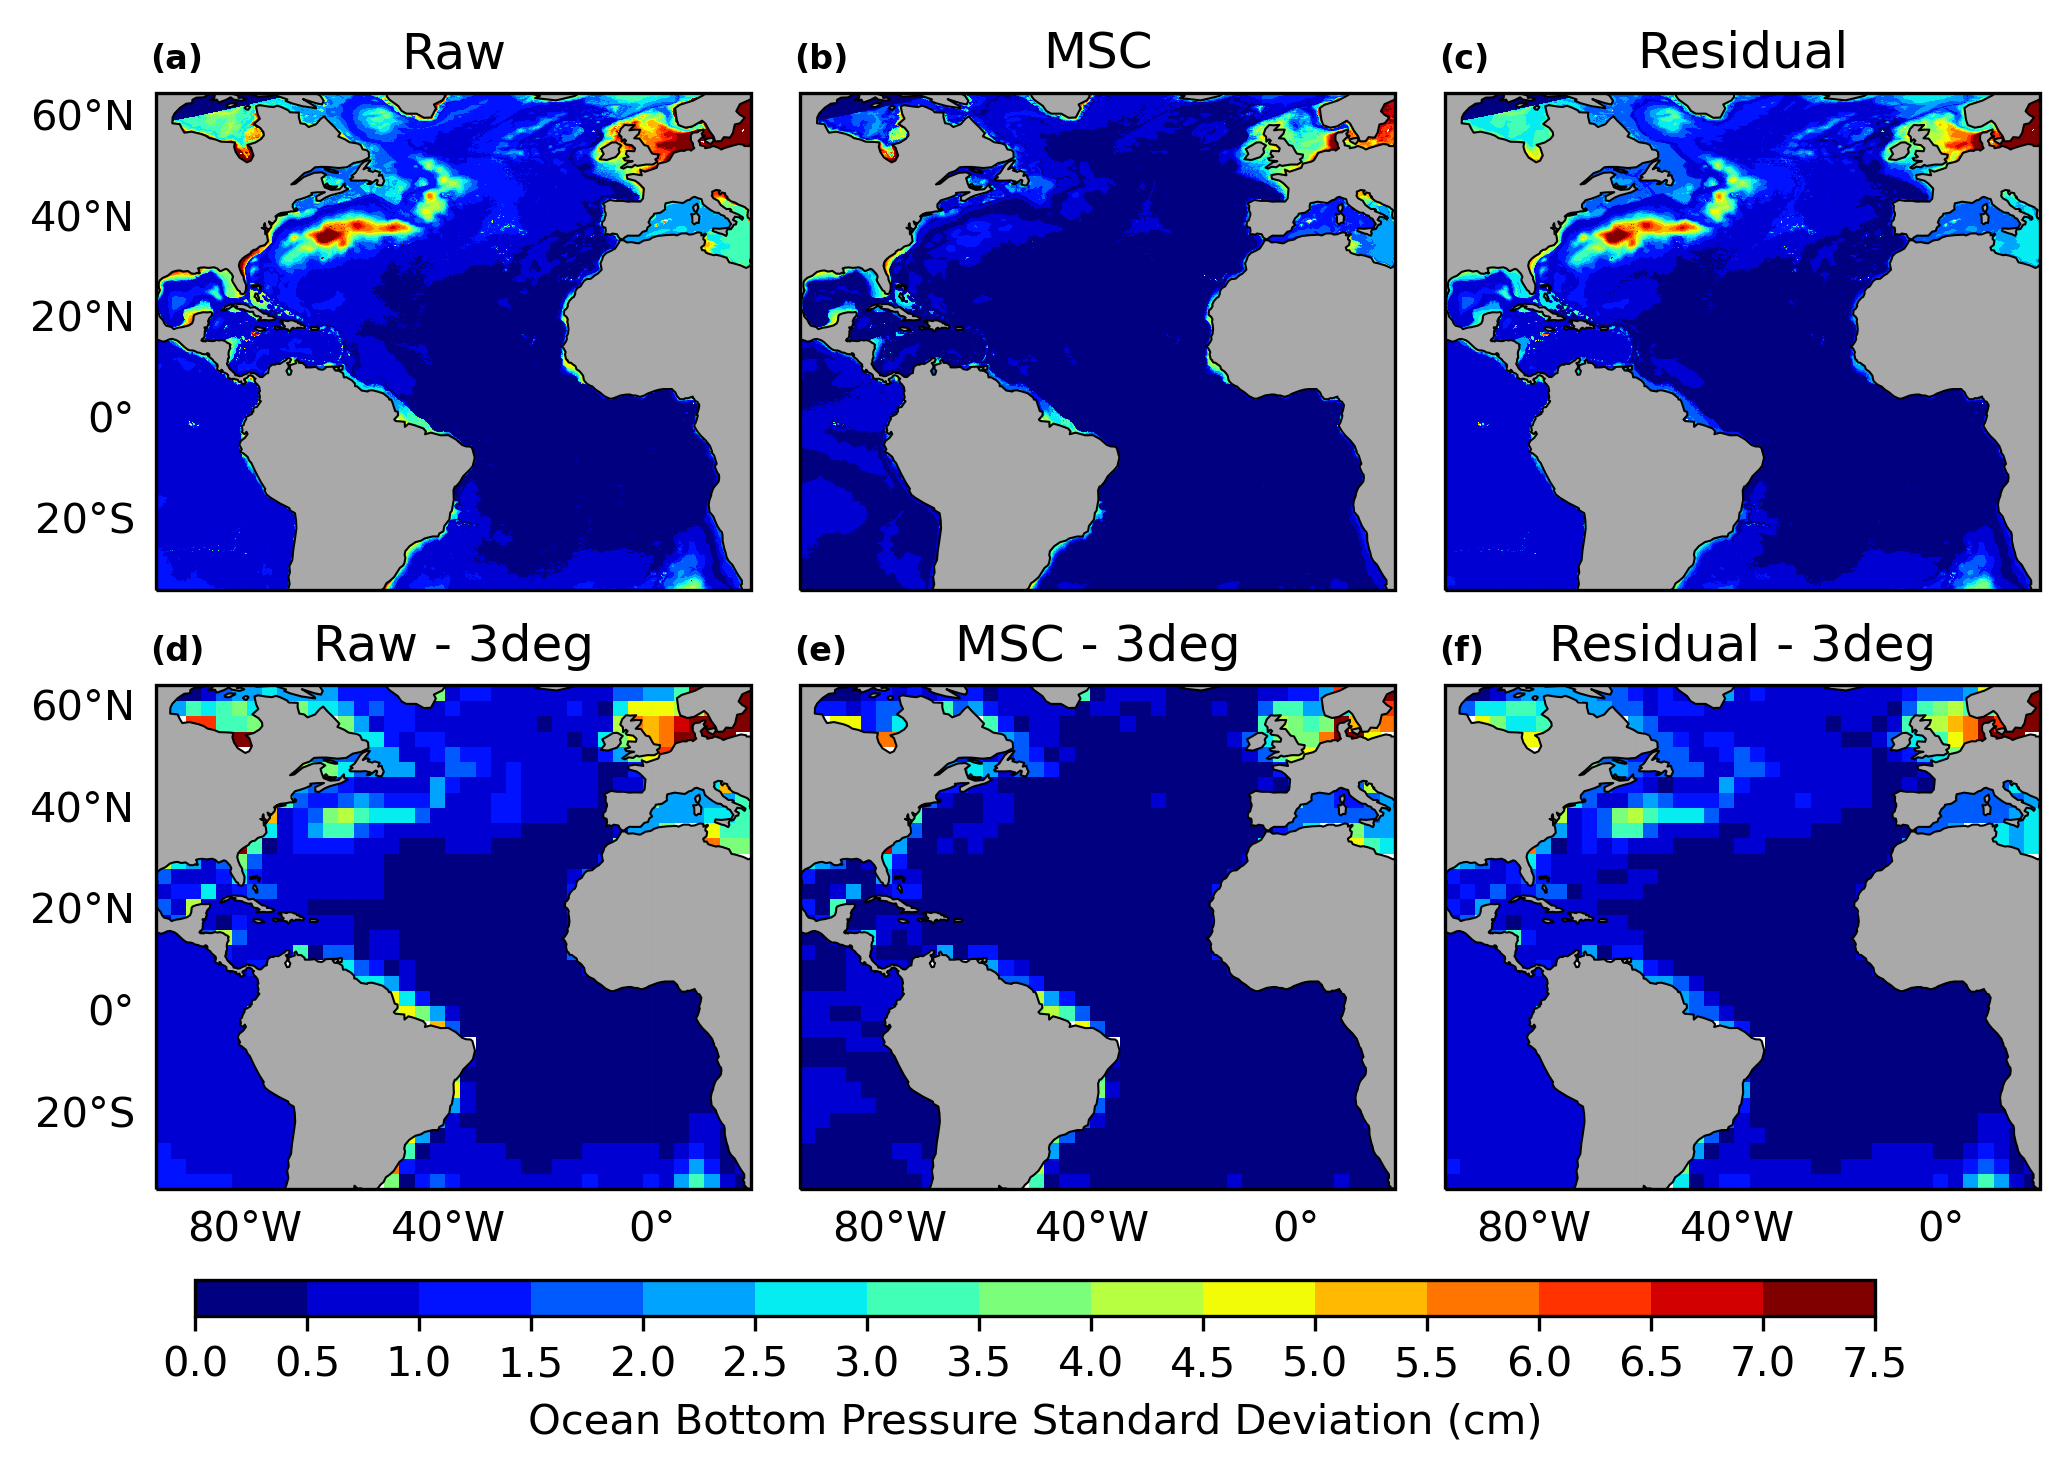

In [94]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(data.lon, 
                       data.lat, 
                       data,
                       transform=ccrs.PlateCarree(), 
                       cmap=cmap,
                       norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black', facecolor='darkgray'
    ))
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM.png", dpi=500, bbox_inches='tight')

plt.show()


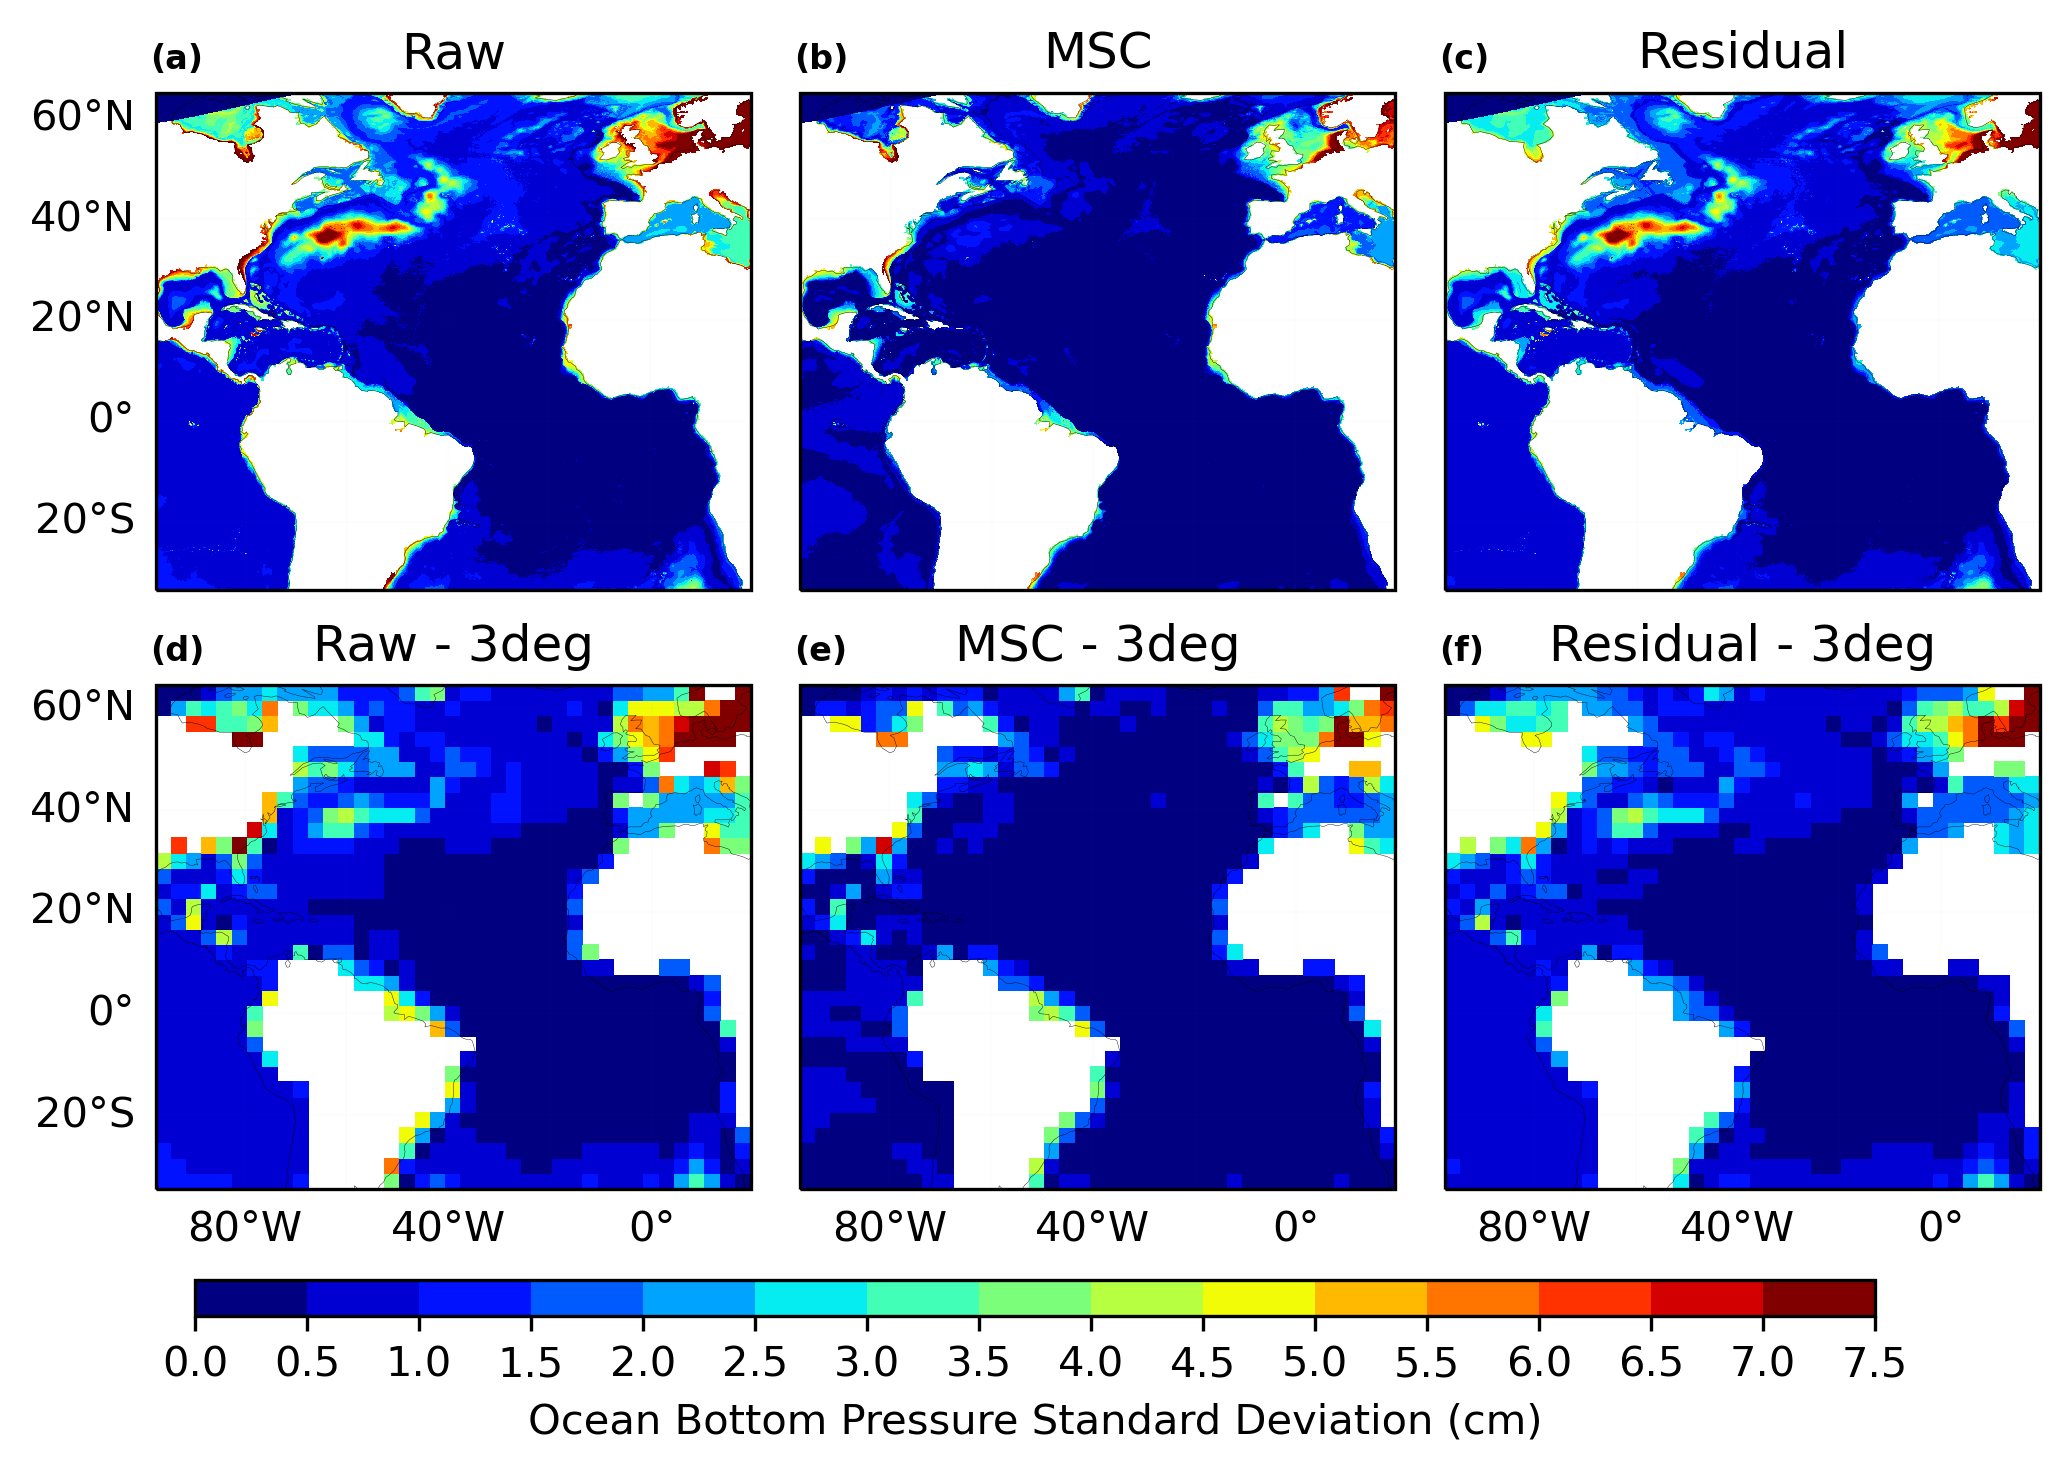

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(data.lon, 
                       data.lat, 
                       data,
                       transform=ccrs.PlateCarree(), 
                       cmap=cmap,
                       norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    #ax.add_feature(cfeature.NaturalEarthFeature(
    #    'physical', 'land', '110m',
    #    linewidth=0.5, edgecolor='black', facecolor='darkgray'
    #))
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='black',
        facecolor='none',
        linewidth=0.1# or 'none' if you want to override below
    )

    ax.add_feature(land, alpha=1)  # 0 = fully transparent, 1 = opaque
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
#plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM.png", dpi=500, bbox_inches='tight')

plt.show()


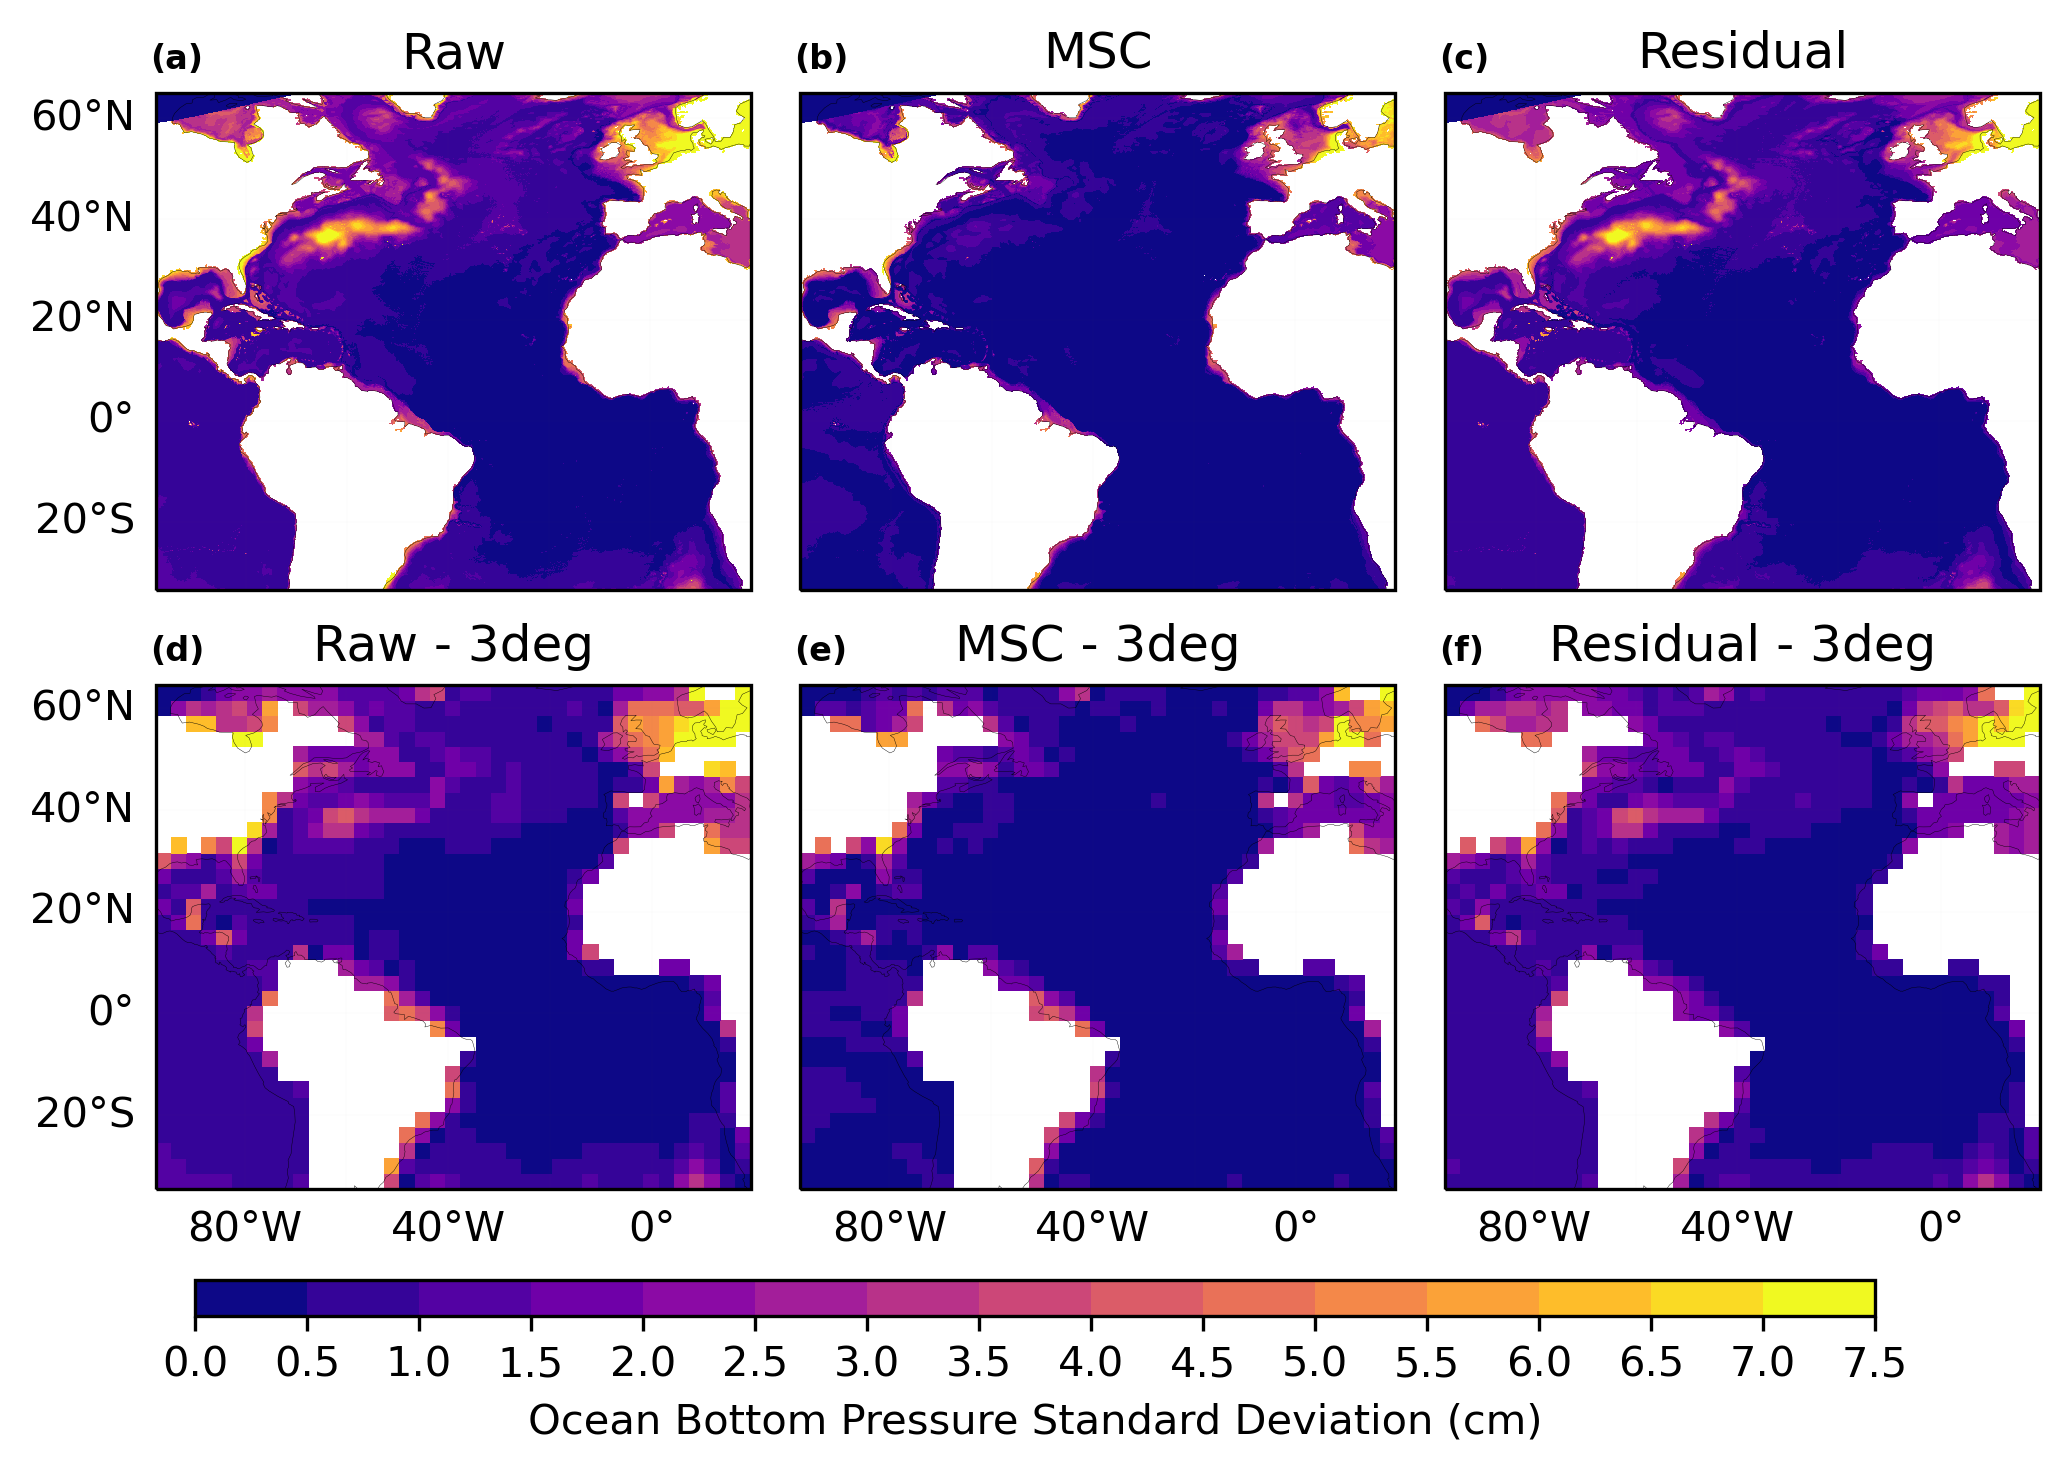

In [105]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("plasma", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(data.lon, 
                       data.lat, 
                       data,
                       transform=ccrs.PlateCarree(), 
                       cmap=cmap,
                       norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    #ax.add_feature(cfeature.NaturalEarthFeature(
    #    'physical', 'land', '110m',
    #    linewidth=0.5, edgecolor='black', facecolor='darkgray'
    #))
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='black',
        facecolor='none',
        linewidth=0.1# or 'none' if you want to override below
    )

    ax.add_feature(land, alpha=1)  # 0 = fully transparent, 1 = opaque
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
#plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM.png", dpi=500, bbox_inches='tight')

plt.show()


In [71]:
std_amazon = std_raw.sel(
    lat=slice(-10, 10),
    lon=slice(-48, -34)
)

std_amazon_3deg = std_raw_3deg.sel(
    lat=slice(-10, 10),
    lon=slice(-48, -34)
)



In [65]:
std_amazon = std_raw.sel(
    lat=slice(-2.97, -0.02),
    lon=slice(-41.99, -39.03)
)

std_amazon_3deg = std_raw_3deg.sel(
    lat=slice(-3, 0),
    lon=slice(-43, -39)
)




(array([9.0226e+04, 8.3500e+02, 8.8700e+02, 7.5800e+02, 5.8500e+02,
        2.8230e+03, 2.5120e+03, 5.0400e+02, 1.8400e+02, 2.0000e+00]),
 array([0.24842791, 0.7693327 , 1.2902374 , 1.8111422 , 2.332047  ,
        2.8529518 , 3.3738565 , 3.8947613 , 4.415666  , 4.936571  ,
        5.4574757 ], dtype=float32),
 <BarContainer object of 10 artists>)

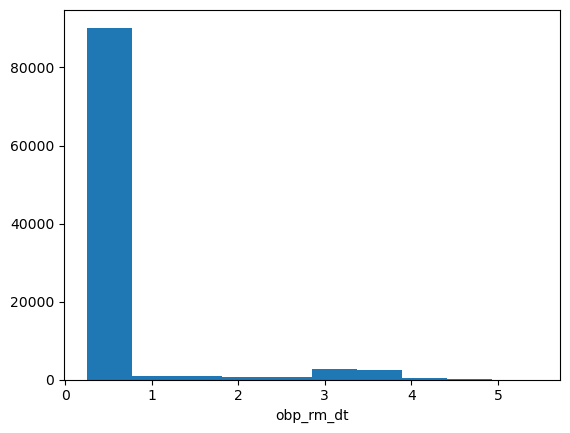

In [72]:
std_amazon.plot.hist()

(array([20.,  0.,  1.,  2.,  0.,  0.,  1.,  0.,  0.,  1.]),
 array([0.2571675 , 0.74096113, 1.2247548 , 1.7085485 , 2.1923423 ,
        2.6761358 , 3.1599295 , 3.6437232 , 4.1275167 , 4.6113105 ,
        5.095104  ], dtype=float32),
 <BarContainer object of 10 artists>)

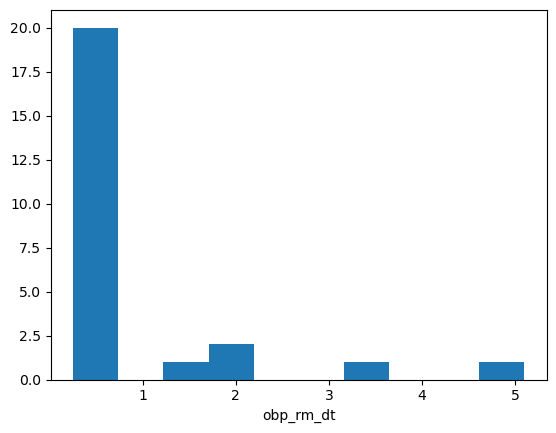

In [73]:
std_amazon_3deg.plot.hist()

In [74]:
std_amazon_3deg

<xarray.DataArray 'obp_rm_dt' (lat: 6, lon: 5)>
array([[       nan,        nan,        nan,        nan, 0.39733517],
       [       nan, 5.095104  , 1.91081   , 0.4894754 , 0.2571675 ],
       [3.5015018 , 2.0178978 , 0.5078462 , 0.2924653 , 0.30114275],
       [1.3854475 , 0.36186782, 0.36725098, 0.34341073, 0.35103315],
       [0.35429978, 0.33634195, 0.32083863, 0.35740033, 0.3623259 ],
       [0.3701393 , 0.31070596, 0.33635527, 0.30016205, 0.30915937]],
      dtype=float32)
Coordinates:
  * lat      (lat) float64 -7.5 -4.5 -1.5 1.5 4.5 7.5
  * lon      (lon) float64 -46.5 -43.5 -40.5 -37.5 -34.5

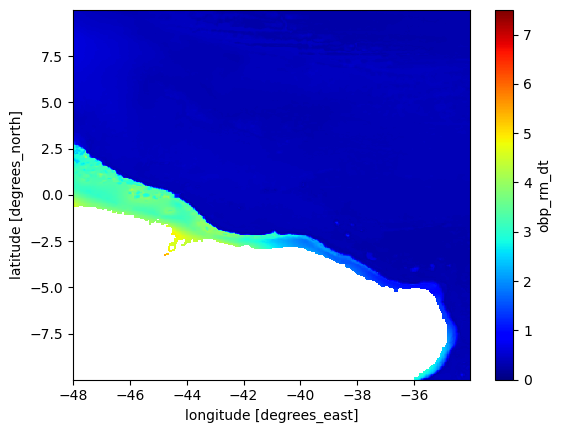

In [75]:
std_amazon.plot(cmap='jet', vmin = 0, vmax =7.5)

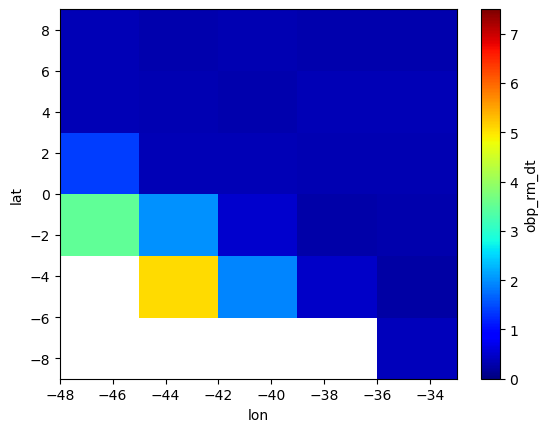

In [76]:
std_amazon_3deg.plot(cmap='jet', vmin = 0, vmax =7.5)

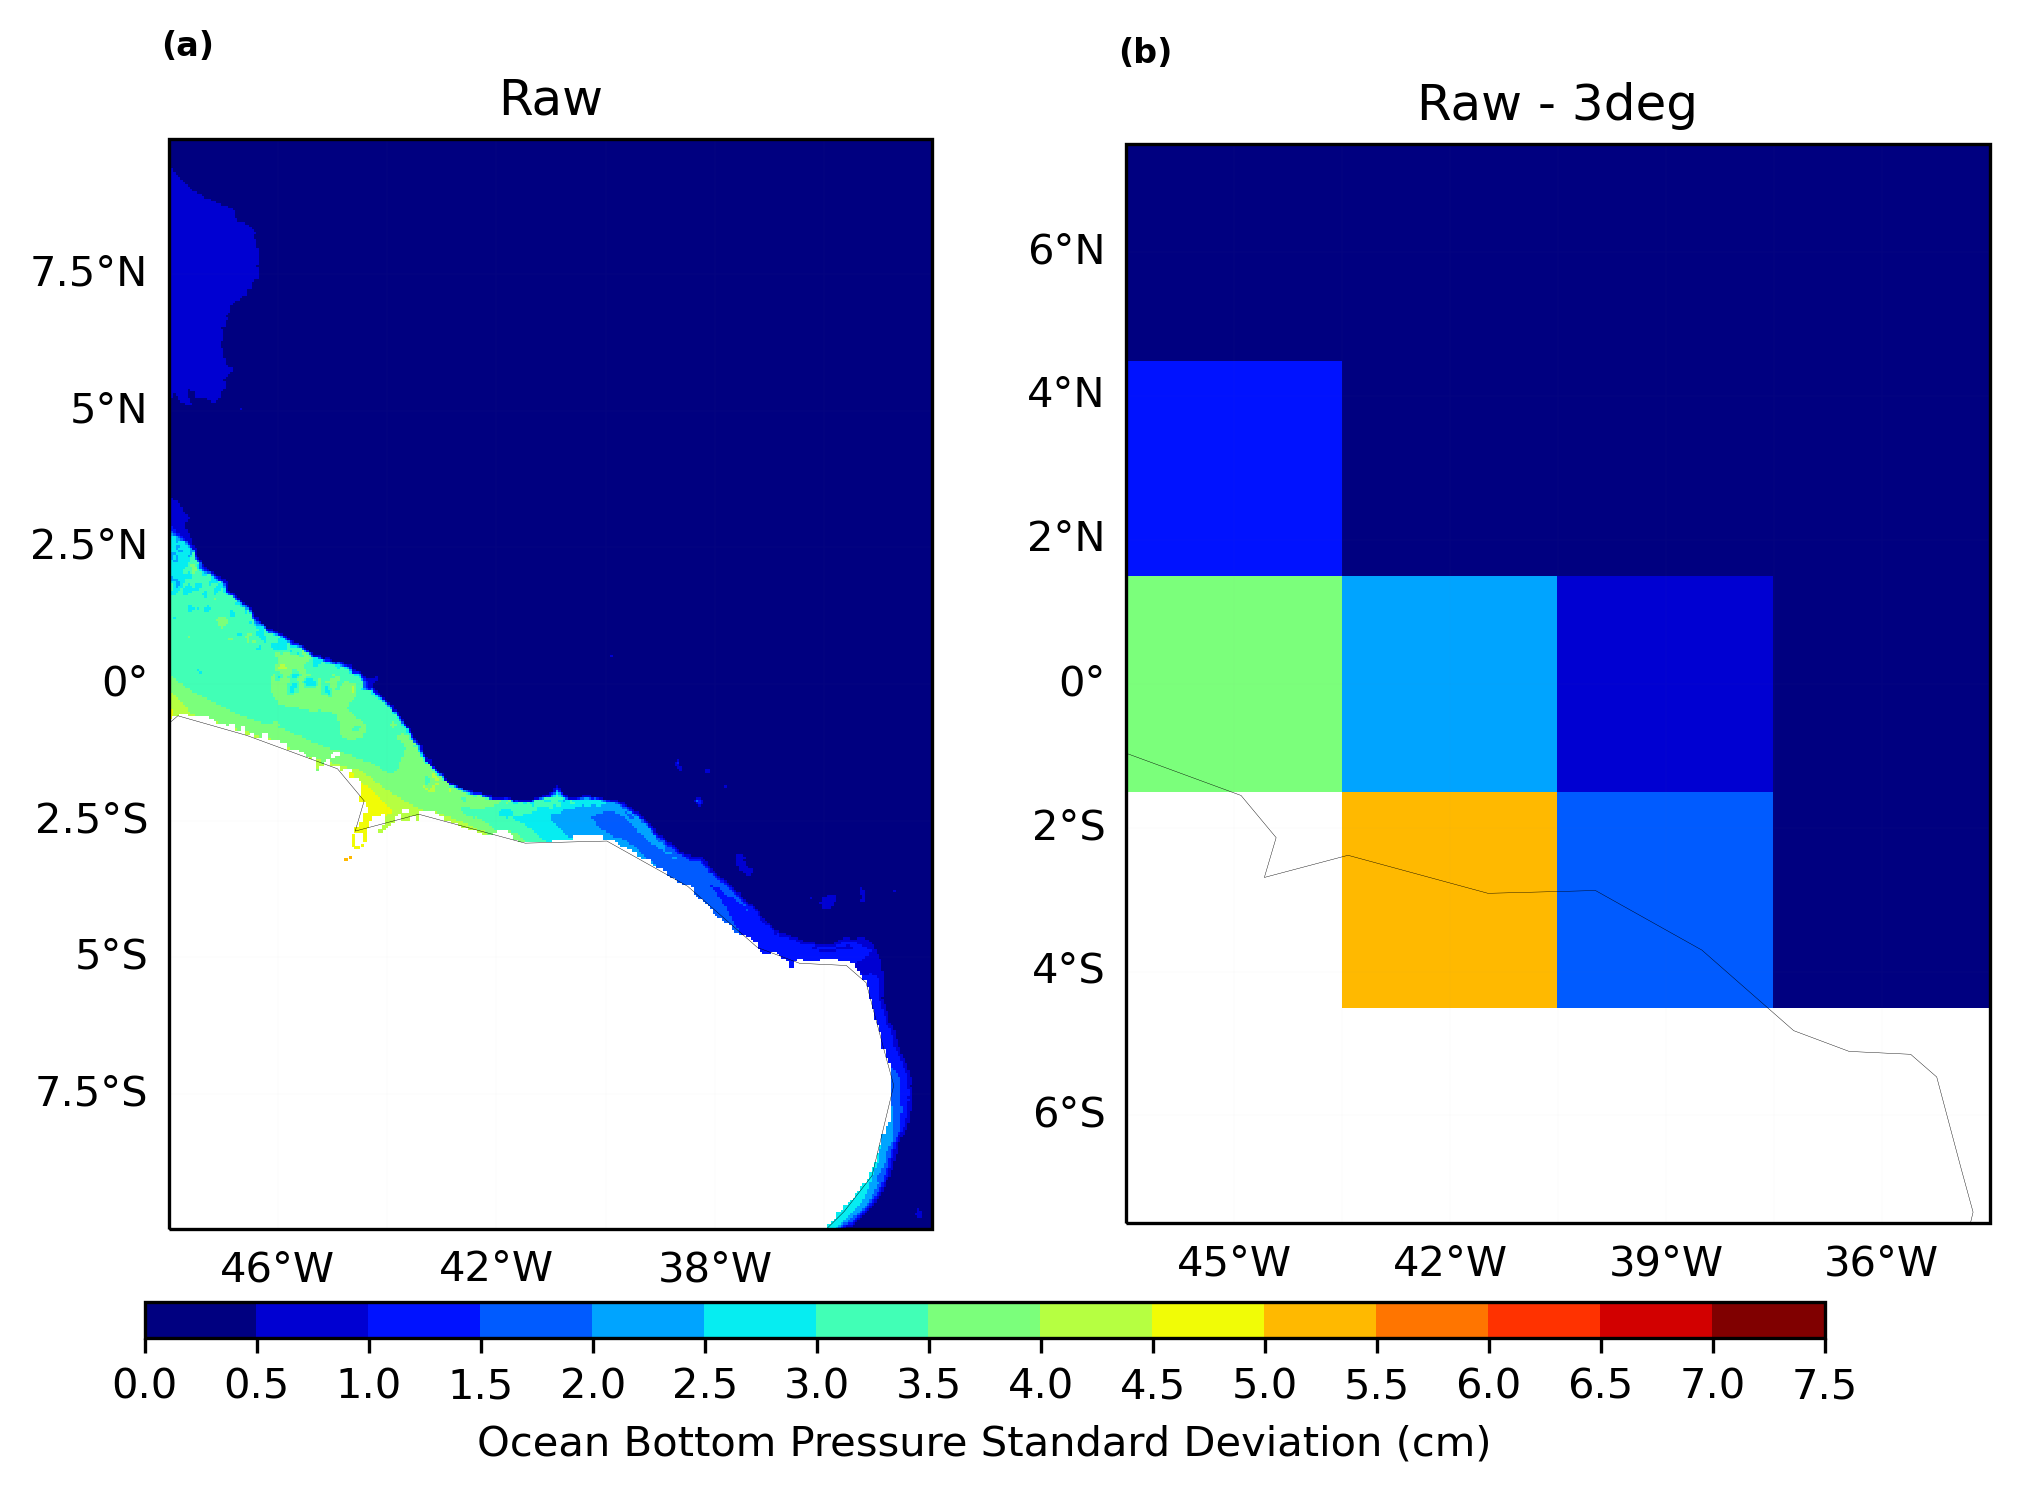

In [81]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_amazon,
    std_amazon_3deg
]

title_list = [
    "Raw", 
    "Raw - 3deg"
]

labels = ['(a)', '(b)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(data.lon, 
                       data.lat, 
                       data,
                       transform=ccrs.PlateCarree(), 
                       cmap=cmap,
                       norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i <= 3
    gl.ylabels_left = True
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    #ax.add_feature(cfeature.NaturalEarthFeature(
    #    'physical', 'land', '110m',
    #    linewidth=0.5, edgecolor='black', facecolor='darkgray'
    #))
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='black',
        facecolor='none',
        linewidth=0.1# or 'none' if you want to override below
    )

    ax.add_feature(land, alpha=1)  # 0 = fully transparent, 1 = opaque
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
#plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM.png", dpi=500, bbox_inches='tight')

plt.show()


In [103]:
print(obp_3deg, viking_ds["obp_rm_dt"])


<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<reshape, shape=(372, 34, 40), dtype=float32, chunksize=(372, 1, 40), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm <xarray.DataArray 'obp_rm_dt' (time: 372, lat: 2267, lon: 2715)>
array([[[-1.247275, -1.207025, ...,       nan,       nan],
        [-1.240865, -1.23057 , ...,       nan,       nan],
        ...,
        [ 0.313619,  0.313619, ...,  0.313619,  0.313619],
        [ 0.313619,  0.313619, ...,  0.313619,  0.313619]],

       [[ 0.3756  ,  0.384585, ...,       nan,       nan],
        [ 0.38201 ,  0.361044, ...,       nan,       nan],
        ...,
 

In [10]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import dask
from dask.diagnostics import ProgressBar

# -------------------------
# Inputs (residual on time)
# -------------------------
obp_hr = viking_ds["obp_rm_dt"]      # (time, lat_hr, lon_hr)  HUGE
obp_lr = obp_3deg        # (time, lat_lr=34, lon_lr=40)

# Core dim "time" must be single chunk for dask='parallelized'
obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})  # tune lat/lon chunks to your system

# -------------------------
# Build bin_id for each hi-res pixel based on low-res 3° bin centers
# -------------------------
lat_c = obp_lr["lat"].values
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

dlat = float(np.median(np.diff(lat_c)))
dlon = float(np.median(np.diff(lon_c)))
lat_edges = np.concatenate([lat_c - dlat/2, [lat_c[-1] + dlat/2]])
lon_edges = np.concatenate([lon_c - dlon/2, [lon_c[-1] + dlon/2]])

ilat = np.digitize(obp_hr["lat"].values, lat_edges) - 1   # (lat_hr,)
ilon = np.digitize(obp_hr["lon"].values, lon_edges) - 1   # (lon_hr,)

ilat[(ilat < 0) | (ilat >= lat_c.size)] = -1
ilon[(ilon < 0) | (ilon >= lon_c.size)] = -1

ilat_da = xr.DataArray(ilat, dims=("lat",), coords={"lat": obp_hr["lat"]})
ilon_da = xr.DataArray(ilon, dims=("lon",), coords={"lon": obp_hr["lon"]})

ilat2d, ilon2d = xr.broadcast(ilat_da, ilon_da)
bin_id_2d = (ilat2d * nlon_lr + ilon2d).astype("int64")
bin_id_2d = bin_id_2d.where((ilat2d >= 0) & (ilon2d >= 0), other=-1)

obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

# -------------------------
# Helpers: corr, counts, p-values
# -------------------------
def corr_1d_nan(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    x = x[m]; y = y[m]
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x*x).sum() * (y*y).sum())
    if denom == 0:
        return np.nan
    return (x*y).sum() / denom

def count_pairs_1d(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return m.sum()

def pval_from_r_n(r, n):
    if (not np.isfinite(r)) or (n < 3):
        return np.nan
    df = n - 2
    r = np.clip(r, -1 + 1e-12, 1 - 1e-12)
    t = r * np.sqrt(df / (1.0 - r*r))
    return 2.0 * stats.t.sf(np.abs(t), df)

alpha = 0.05

# -------------------------
# Stack hi-res space; group within each 3° bin; correlate bin series vs each point
# -------------------------
obp_stack = obp_hr.stack(points=("lat", "lon"))
obp_stack = obp_stack.where(obp_stack["bin_id"] >= 0, drop=True)
g = obp_stack.groupby("bin_id")

def corr_group_with_sig(y):
    """
    y: DataArray (time, points_in_bin) for one bin_id
    returns: Dataset with r, p, sig over points_in_bin
    """
    bid = int(y["bin_id"].values[0])
    ilat = bid // nlon_lr
    ilon = bid %  nlon_lr

    x = obp_lr.isel(lat=ilat, lon=ilon).chunk({"time": -1})
    y = y.chunk({"time": -1})

    r_bin = xr.apply_ufunc(
        corr_1d_nan,
        x, y,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    n_bin = xr.apply_ufunc(
        count_pairs_1d,
        x, y,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.int16],
    )

    p_bin = xr.apply_ufunc(
        pval_from_r_n,
        r_bin, n_bin,
        input_core_dims=[[], []],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float64],
    )

    sig_bin = xr.where(p_bin < alpha, 1, 0).astype(np.int8).where(np.isfinite(p_bin))
    return xr.Dataset({"r": r_bin, "p": p_bin, "sig": sig_bin})

out_points = g.map(corr_group_with_sig)

# Unstack back to hi-res grids
r_hr   = out_points["r"].unstack("points").rename("corr_bin_vs_pixel_res")
p_hr   = out_points["p"].unstack("points").rename("pval_bin_vs_pixel_res")
sig_hr = out_points["sig"].unstack("points").rename("sigmask_bin_vs_pixel_res")

# -------------------------
# Compute (WARNING: global hi-res compute is extremely heavy)
# -------------------------
# Strongly recommend subsetting to a basin before compute:
# r_hr = r_hr.sel(lat=slice(...), lon=slice(...))
# same for p_hr, sig_hr

with ProgressBar():
    r_hr_c, p_hr_c, sig_hr_c = dask.compute(r_hr, p_hr, sig_hr)


[########################################] | 100% Completed | 526.00 s


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# --- Colormap for difference panel (-0.03..0.03 by 0.005) ---
boundaries2 = np.arange(-1, 1.1, 0.1)   # include 0.03
base2 = plt.cm.get_cmap("coolwarm", len(boundaries2))
cmap2 = ListedColormap(base2(np.arange(base2.N)))
norm2 = BoundaryNorm(boundaries2, ncolors=cmap2.N)

def plot_corr_with_stippling(r, sig_mask, title="", extent=None, stride=5):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj)
    if extent is not None:
        ax.set_extent(extent, crs=proj)
        
    pm = ax.pcolormesh(
        r["lon"].values, r["lat"].values, r.values,
        transform=proj, 
        cmap=cmap2, norm=norm2, shading="auto"
    )

    levels = [200, 3000]
    cs = ax.contour(
        b_lon, b_lat, b_field,
        levels=levels, colors="yellow", linewidths=0.4,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(cs, fmt="%d m", fontsize=4)
    cb = plt.colorbar(pm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation Coefficient")

    gl = ax.gridlines(color='gray', linestyle='--', linewidth=0.2, draw_labels=False)
    gl.bottom_labels = True
    gl.left_labels = True

    #ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    #ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # Stippling: plot points where sig_mask == 1, decimated by stride for speed
    sig = (sig_mask == 0)
    sig_dec = sig.isel(lat=slice(None, None, stride), lon=slice(None, None, stride))

    lon2d, lat2d = np.meshgrid(sig_dec["lon"].values, sig_dec["lat"].values)
    ax.scatter(
        lon2d[sig_dec.values],
        lat2d[sig_dec.values],
        s=1,
        transform=proj,
        linewidths=0,
        color = '#636363',
        
    )

    ax.set_title(title or "Correlation with significance stippling (mask==1)")
    plt.tight_layout()
    plt.savefig("VIKING_OBP_Binned_Correlation_raw_TM.png", dpi=500, bbox_inches='tight')
    plt.show()

# Example:


In [17]:
bathy = xr.open_dataset('/glade/work/netige/Data/Bathymetry/GLO-MFC_001_030_mask_bathy.nc')

In [18]:
data32 = bathy["deptho"].astype("float32")            # meters, positive down
data32 = data32.where(np.isfinite(data32)) 

data32 = data32.sel(
    latitude=slice(-33.5, 65),
    longitude=slice(-98, 20)
)
b_lat = data32["latitude"]; b_lon = data32["longitude"]; b_field = data32


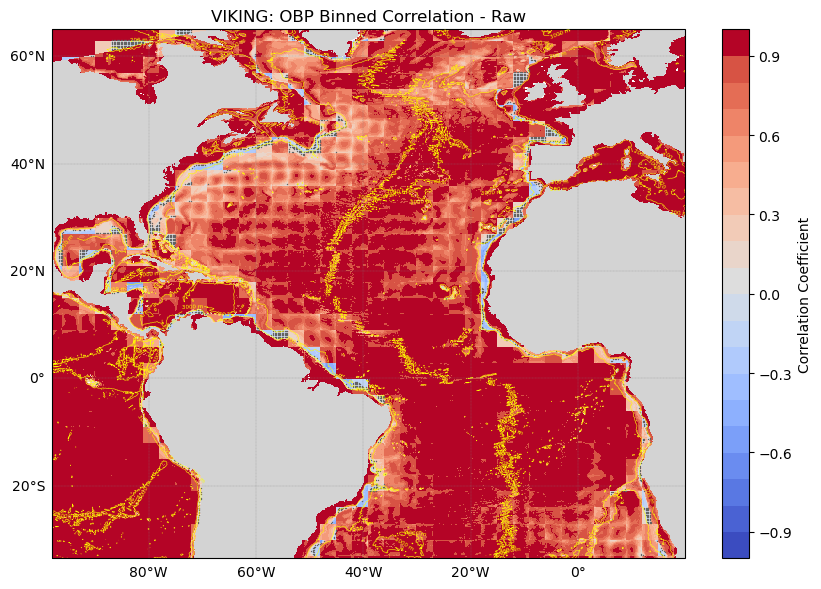

In [19]:
plot_corr_with_stippling(r_hr_c, sig_hr_c, title="VIKING: OBP Binned Correlation - Raw", stride=6)

### Compute normalized std dif between binned and HR OBP

In [21]:
import numpy as np
import xarray as xr
import dask
from dask.diagnostics import ProgressBar

def std_1d_nan(x):
    m = np.isfinite(x)
    if m.sum() < 2:
        return np.nan
    return np.std(x[m], ddof=1)

def std_resid_over_std_hr(x_lr, y_hr):
    """
    x_lr: 1D array (time,) LR bin series
    y_hr: 1D array (time,) HR pixel series
    returns: std(time)[y_hr - x_lr] / std(time)[y_hr]
    """
    m = np.isfinite(x_lr) & np.isfinite(y_hr)
    if m.sum() < 2:
        return np.nan
    r = y_hr[m] - x_lr[m]
    num = np.std(r, ddof=1)
    den = np.std(y_hr[m], ddof=1)
    if (not np.isfinite(den)) or den == 0:
        return np.nan
    return num / den


In [8]:
# -------------------------
# Inputs (residual on time)
# -------------------------
obp_hr = viking_ds["obp_rm_dt"]      # (time, lat_hr, lon_hr)  HUGE
obp_lr = obp_3deg        # (time, lat_lr=34, lon_lr=40)

# Core dim "time" must be single chunk for dask='parallelized'
obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})  # tune lat/lon chunks to your system

# -------------------------
# Build bin_id for each hi-res pixel based on low-res 3° bin centers
# -------------------------
lat_c = obp_lr["lat"].values
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

dlat = float(np.median(np.diff(lat_c)))
dlon = float(np.median(np.diff(lon_c)))
lat_edges = np.concatenate([lat_c - dlat/2, [lat_c[-1] + dlat/2]])
lon_edges = np.concatenate([lon_c - dlon/2, [lon_c[-1] + dlon/2]])

ilat = np.digitize(obp_hr["lat"].values, lat_edges) - 1   # (lat_hr,)
ilon = np.digitize(obp_hr["lon"].values, lon_edges) - 1   # (lon_hr,)

ilat[(ilat < 0) | (ilat >= lat_c.size)] = -1
ilon[(ilon < 0) | (ilon >= lon_c.size)] = -1

ilat_da = xr.DataArray(ilat, dims=("lat",), coords={"lat": obp_hr["lat"]})
ilon_da = xr.DataArray(ilon, dims=("lon",), coords={"lon": obp_hr["lon"]})

ilat2d, ilon2d = xr.broadcast(ilat_da, ilon_da)
bin_id_2d = (ilat2d * nlon_lr + ilon2d).astype("int64")
bin_id_2d = bin_id_2d.where((ilat2d >= 0) & (ilon2d >= 0), other=-1)

obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

In [23]:
# -------------------------
# Inputs (same as before)
# -------------------------
#obp_hr = viking_ds["obp_rm_dt"]     # (time, lat_hr, lon_hr)
#obp_lr = obp_3deg                  # (time, lat_lr, lon_lr)

# Chunking: time must be single chunk for dask='parallelized' core dims
#obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
#obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})

# obp_hr must already have bin_id coord as you constructed earlier:
# obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

# -------------------------
# Stack and group
# -------------------------
obp_stack = obp_hr.stack(points=("lat", "lon"))
obp_stack = obp_stack.where(obp_stack["bin_id"] >= 0, drop=True)
g = obp_stack.groupby("bin_id")

# Need these from earlier binning logic
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

def nsd_group(y):
    """
    y: DataArray (time, points_in_bin) for one bin_id
    returns: Dataset with nsd, std_resid, std_hr over points_in_bin
    """
    # Grab the original points index (MultiIndex) BEFORE we drop coords
    pts_index = y.indexes["points"]          # <-- this is the key
    pts_coord = xr.IndexVariable("points", pts_index)

    bid = int(y["bin_id"].values[0])
    ilat = bid // nlon_lr
    ilon = bid %  nlon_lr

    # LR series (time,) drop scalar coords to avoid conflicts
    x = obp_lr.isel(lat=ilat, lon=ilon).reset_coords(drop=True).chunk({"time": -1})

    # HR group (time, points) drop coords (keep dimension)
    y0 = y.reset_coords(drop=True).chunk({"time": -1})

    # ---- compute metrics
    nsd = xr.apply_ufunc(
        std_resid_over_std_hr,
        x, y0,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    std_resid = xr.apply_ufunc(
        lambda x_lr, y_hr: std_1d_nan(y_hr - x_lr),
        x, y0,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    std_hr = xr.apply_ufunc(
        std_1d_nan,
        y0,
        input_core_dims=[["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    # ---- FORCE all outputs to share the exact same points index object
    nsd = nsd.assign_coords(points=pts_coord)
    std_resid = std_resid.assign_coords(points=pts_coord)
    std_hr = std_hr.assign_coords(points=pts_coord)

    return xr.Dataset({"nsd": nsd, "std_resid": std_resid, "std_hr": std_hr})

out_points = g.map(nsd_group)

nsd_hr       = out_points["nsd"].unstack("points").rename("std_resid_over_std_hr")
std_resid_hr = out_points["std_resid"].unstack("points").rename("std_resid")
std_hr_hr    = out_points["std_hr"].unstack("points").rename("std_hr")

# -------------------------
# Compute (still heavy globally)
# -------------------------
# Strongly recommended: subset before compute
# nsd_hr = nsd_hr.sel(lat=slice(...), lon=slice(...))

#with ProgressBar():
#    nsd_hr_c, std_resid_hr_c, std_hr_hr_c = dask.compute(nsd_hr, std_resid_hr, std_hr_hr)


In [24]:
with ProgressBar():
    nsd_hr_c, std_resid_hr_c, std_hr_hr_c = dask.compute(nsd_hr, std_resid_hr, std_hr_hr)


[########################################] | 100% Completed | 407.79 s


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_nsd_map_discrete_greenbin(
    nsd,
    title="",
    extent=None,
    savepath="VIKING_OBP_NSD_discrete.png",
    bathy_contours=(200, 3000),
):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj)

    if extent is not None:
        ax.set_extent(extent, crs=proj)

    # --- Bin edges:
    # 0..1 by 0.1 gives 10 bins, then add one extra tiny bin for (>1) to show green on the colorbar.
    boundaries = np.r_[np.arange(0.0, 1.0, 0.1), 1.0, 1.0 + 0.1]  # length 12 -> 11 bins

    # --- Colors:
    # 10 plasma bins for [0,1], plus 1 green bin for (>1)
    plasma = plt.cm.get_cmap("Reds_r")
    plasma_colors = plasma(np.linspace(0.0, 1.0, 10))     # 10 discrete colors
    green = np.array([[66/255, 146/255, 198/255, 1.0]])              # RGBA
    cmap = ListedColormap(np.vstack([plasma_colors, green]))  # 11 colors total

    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

    pm = ax.pcolormesh(
        nsd["lon"].values, nsd["lat"].values, nsd.values,
        transform=proj,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    # --- bathymetry contours (assumes b_lon, b_lat, b_field exist)
    if bathy_contours is not None:
        cs = ax.contour(
            b_lon, b_lat, b_field,
            levels=list(bathy_contours),
            colors="yellow",
            linewidths=0.4,
            transform=proj
        )
        ax.clabel(cs, fmt="%d m", fontsize=4)

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    gl = ax.gridlines(color="gray", linestyle="--", linewidth=0.2, draw_labels=False)
    gl.bottom_labels = True
    gl.left_labels = True

    # --- Colorbar ticks must be exactly 0..1 by 0.1
    ticks = np.arange(0.0, 1.0 + 0.1, 0.1)

    cb = plt.colorbar(
        pm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        ticks=ticks,
        boundaries=boundaries,
        spacing="proportional"
    )
    #cb.set_label("NSD = std(HR − LR) / std(HR)")
    cb.set_ticklabels([f"{t:.1f}" for t in ticks])

    ax.set_title(title or "NSD (discrete plasma 0–1; green > 1)")
    plt.tight_layout()
    plt.savefig(savepath, dpi=500, bbox_inches="tight")
    plt.show()


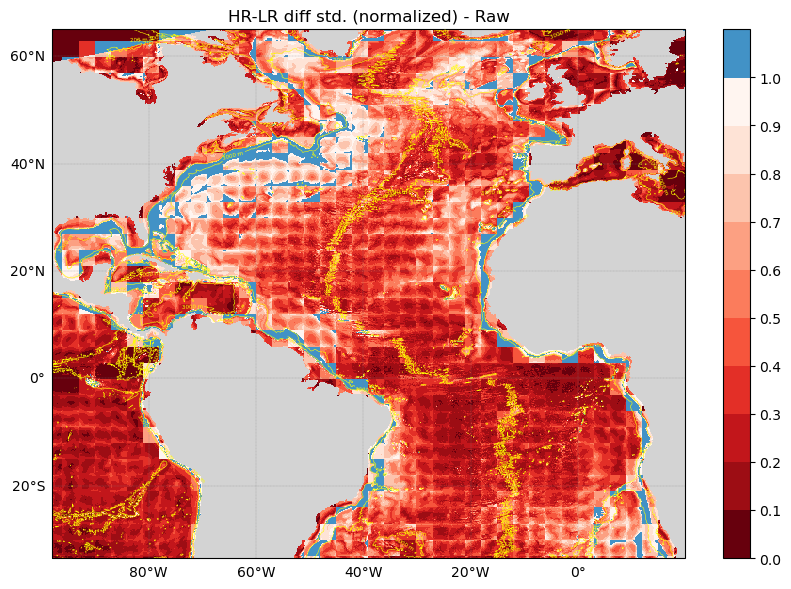

In [28]:
plot_nsd_map_discrete_greenbin(
    nsd_hr_c,
    title="HR-LR diff std. (normalized) - Raw",
    savepath="VIKING_OBP_NSD_raw_TM.png"
)


### Roughwork

In [20]:
# -------------------------
# Inputs (residual on time)
# -------------------------
obp_hr = viking_ds["obp_rm_dt"]      # (time, lat_hr, lon_hr)  HUGE
obp_lr = obp_3deg        # (time, lat_lr=34, lon_lr=40)

# Core dim "time" must be single chunk for dask='parallelized'
obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})  # tune lat/lon chunks to your system

# -------------------------
# Build bin_id for each hi-res pixel based on low-res 3° bin centers
# -------------------------
lat_c = obp_lr["lat"].values
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

dlat = float(np.median(np.diff(lat_c)))
dlon = float(np.median(np.diff(lon_c)))
lat_edges = np.concatenate([lat_c - dlat/2, [lat_c[-1] + dlat/2]])
lon_edges = np.concatenate([lon_c - dlon/2, [lon_c[-1] + dlon/2]])

ilat = np.digitize(obp_hr["lat"].values, lat_edges) - 1   # (lat_hr,)
ilon = np.digitize(obp_hr["lon"].values, lon_edges) - 1   # (lon_hr,)

ilat[(ilat < 0) | (ilat >= lat_c.size)] = -1
ilon[(ilon < 0) | (ilon >= lon_c.size)] = -1

ilat_da = xr.DataArray(ilat, dims=("lat",), coords={"lat": obp_hr["lat"]})
ilon_da = xr.DataArray(ilon, dims=("lon",), coords={"lon": obp_hr["lon"]})

ilat2d, ilon2d = xr.broadcast(ilat_da, ilon_da)
bin_id_2d = (ilat2d * nlon_lr + ilon2d).astype("int64")
bin_id_2d = bin_id_2d.where((ilat2d >= 0) & (ilon2d >= 0), other=-1)

obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

In [84]:
obp_hr = viking_ds["obp_rm_dt"].chunk({"time": -1, "lat": 200, "lon": 200})
obp_3deg = obp_3deg.chunk({"time": -1, "lat": -1, "lon": -1})

obp_3deg_on_hr = obp_3deg.interp(lat=obp_hr["lat"], lon=obp_hr["lon"], method="nearest")

corr_3deg = xr.corr(obp_hr, obp_3deg_on_hr, dim="time")


In [71]:
with ProgressBar():
    corr_3deg_c = corr_3deg.compute()

[########################################] | 100% Completed | 75.47 s


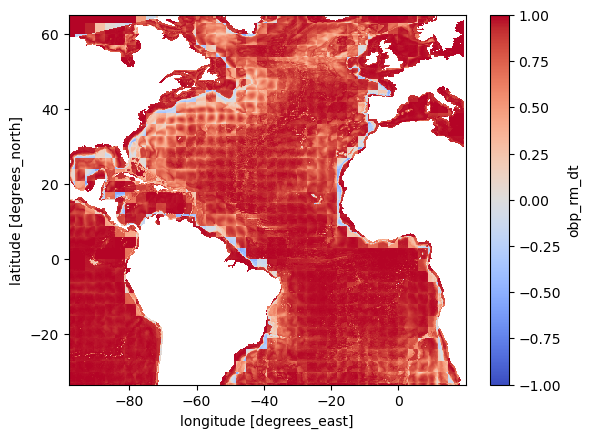

In [85]:
corr_3deg_c.plot(cmap = "coolwarm"
            )

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

def plot_bullseye_bin_timeseries(
    obp_hr: xr.DataArray,
    obp_lr: xr.DataArray,
    bin_id: int,
    *,
    time_slice=None,          # e.g., slice("1998-01-01","2005-12-31")
    label="OBP",
    lw=2.0,
):
    """
    For a given bin_id, plot:
      - LR bin time series (obp_lr at corresponding (ilat, ilon))
      - HR center pixel time series inside that bin
      - HR north/south/east/west edge pixel time series inside that bin
    """

    # Map bin_id -> LR indices (must match your bin construction: bin_id = ilat*nlon + ilon)
    nlon_lr = obp_lr.sizes["lon"]
    ilat_lr = bin_id // nlon_lr
    ilon_lr = bin_id %  nlon_lr

    # Optional time subset
    if time_slice is not None:
        obp_hr_use = obp_hr.sel(time=time_slice)
        obp_lr_use = obp_lr.sel(time=time_slice)
    else:
        obp_hr_use = obp_hr
        obp_lr_use = obp_lr

    # LR series for that bin
    bin_ts = obp_lr_use.isel(lat=ilat_lr, lon=ilon_lr).compute()

    # Build mask for this bin (compute only this 2D boolean)
    mask2d = (obp_hr_use["bin_id"] == bin_id).compute()

    n_in = int(mask2d.sum().values)
    if n_in == 0:
        raise ValueError(f"No HR pixels found for bin_id={bin_id}. Check bin_id mapping.")

    # Get indices (ilat_idx, ilon_idx) of pixels in bin
    ij = np.argwhere(mask2d.values)  # shape (Npix, 2)
    ilat_idx = ij[:, 0]
    ilon_idx = ij[:, 1]

    lat_vals = obp_hr_use["lat"].values
    lon_vals = obp_hr_use["lon"].values
    lat_in = lat_vals[ilat_idx]
    lon_in = lon_vals[ilon_idx]

    # Center pixel: closest to centroid in lat/lon
    lat_c = float(np.nanmean(lat_in))
    lon_c = float(np.nanmean(lon_in))
    d2 = (lat_in - lat_c)**2 + (lon_in - lon_c)**2
    k_center = int(np.argmin(d2))

    # Edge pixels
    k_north = int(np.argmax(lat_in))
    k_south = int(np.argmin(lat_in))
    k_east  = int(np.argmax(lon_in))
    k_west  = int(np.argmin(lon_in))

    picks = {
        "center": (ilat_idx[k_center], ilon_idx[k_center]),
        "ne":  (ilat_idx[k_north],  ilon_idx[k_east]),
        "sw":  (ilat_idx[k_south],  ilon_idx[k_west]),
        "nw":   (ilat_idx[k_north],   ilon_idx[k_west]),
        "se":   (ilat_idx[k_south],   ilon_idx[k_east]),
    }

    # Extract HR time series (tiny reads)
    hr_series = {}
    for name, (ii, jj) in picks.items():
        hr_series[name] = obp_hr_use.isel(lat=ii, lon=jj).compute()

    # ---- Plot
    fig, ax = plt.subplots(figsize=(13, 4.5))

    ax.plot(bin_ts["time"].values, bin_ts.values,
            label=f"{label} LR bin mean (bin_id={bin_id})", linewidth=3.0, color="k")

    for name, ts in hr_series.items():
        ii, jj = picks[name]
        ax.plot(ts["time"].values, ts.values,
                label=f"{label} HR {name} (lat={float(lat_vals[ii]):.2f}, lon={float(lon_vals[jj]):.2f})",
                linewidth=lw, alpha=0.9)

    ax.set_title(f"{label}: bullseye bin diagnostic | bin_id={bin_id} -> LR(lat={ilat_lr}, lon={ilon_lr})")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{label} ({obp_hr.attrs.get('units','')})")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return {"bin_id": bin_id, "lr_index": (ilat_lr, ilon_lr), "hr_picks": picks, "n_pixels_in_bin": n_in}


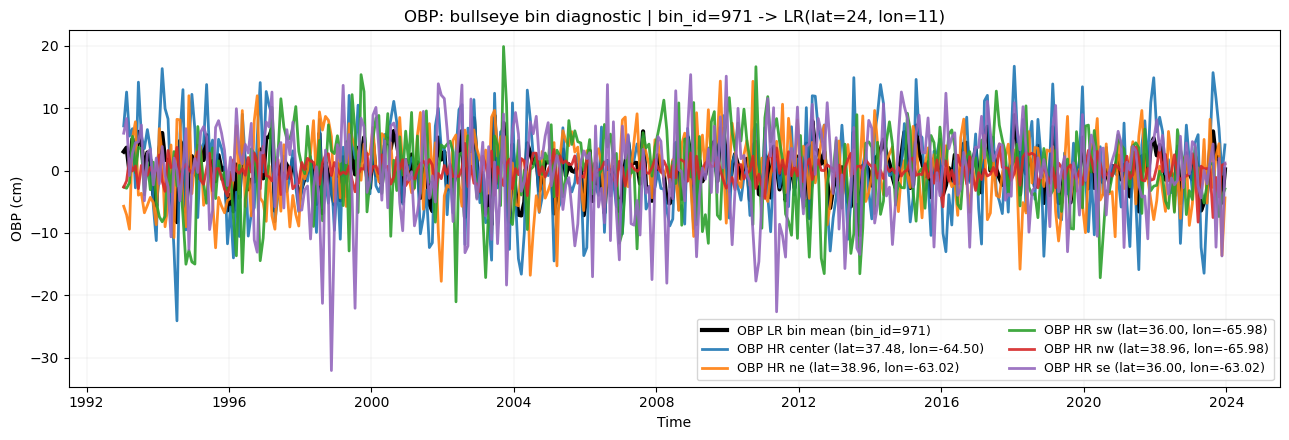

In [89]:
out = plot_bullseye_bin_timeseries(
    obp_hr=obp_hr,
    obp_lr=obp_lr,
    bin_id=971,  # <-- pick a bullseye bin_id from your map
    time_slice=slice("1993-01-01", "2023-12-31"),
    label="OBP"
)



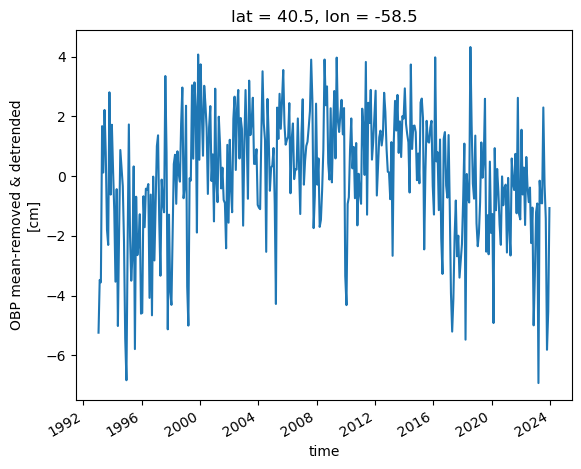

In [99]:
obp_lr.isel(lat = 25, lon = 13).plot()

In [100]:
34*40

1360

In [101]:
obp_lr

<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<rechunk-merge, shape=(372, 34, 40), dtype=float32, chunksize=(372, 34, 40), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm

In [102]:
(24*40)+14

974

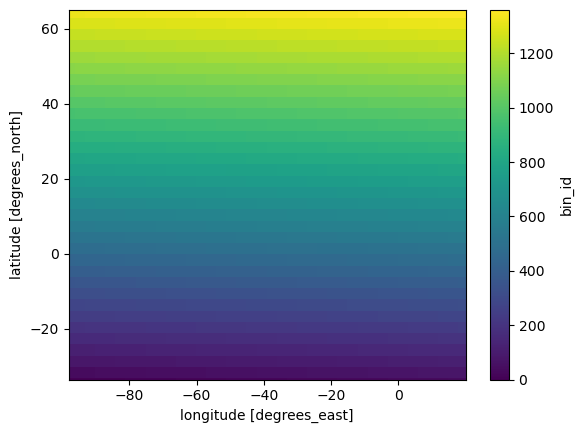

In [103]:
obp_hr.bin_id.plot()

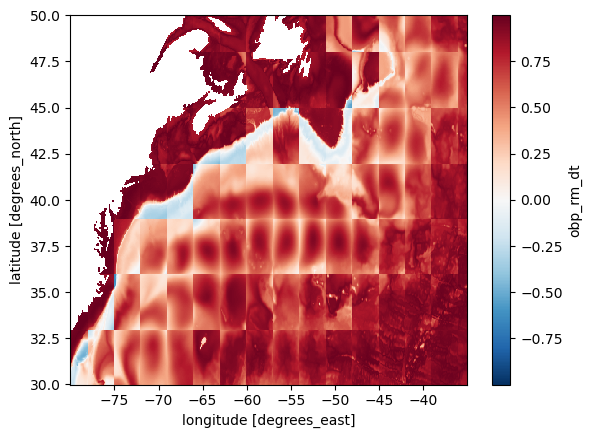

In [104]:
# Gulf Stream / Extension box (adjust as you like)
gs_extent = dict(lon=slice(-80, -35), lat=slice(30, 50))

corr_gs = corr_3deg_c.sel(**gs_extent)

corr_gs.plot()

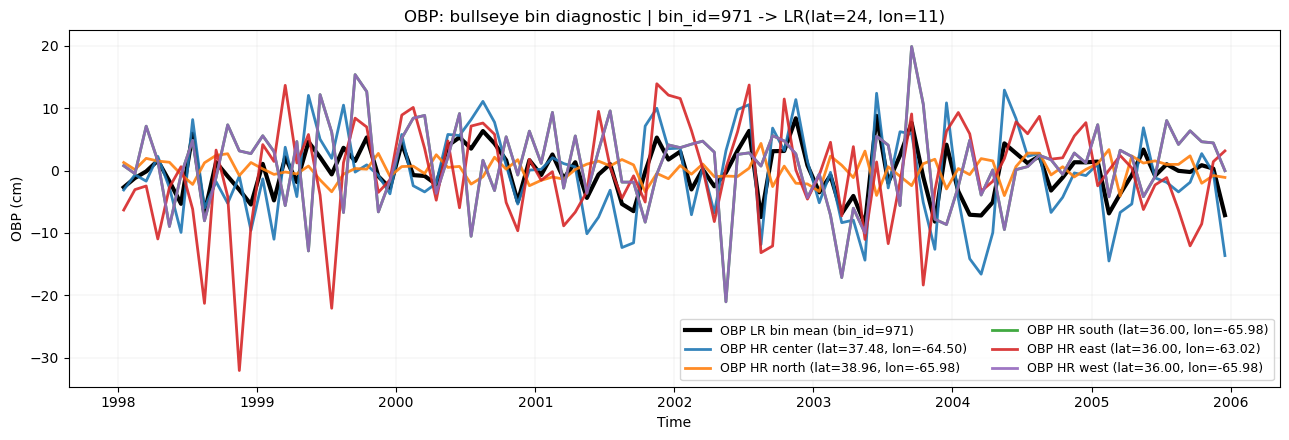

In [64]:
out = plot_bullseye_bin_timeseries(
    obp_hr=obp_hr,
    obp_lr=obp_lr,
    bin_id=971,  # <-- pick a bullseye bin_id from your map
    time_slice=slice("1998-01-01", "2005-12-31"),
    label="OBP"
)
#print(out)


In [90]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

def plot_bullseye_bin_timeseries(
    obp_hr: xr.DataArray,
    obp_lr: xr.DataArray,
    bin_id: int,
    *,
    time_slice=None,          # e.g., slice("1998-01-01","2005-12-31")
    label="OBP",
    lw=2.0,
    print_corr=True,
):
    """
    For a given bin_id, plot:
      - LR bin time series (obp_lr at corresponding (ilat, ilon))
      - HR center pixel time series inside that bin
      - HR north/south/east/west edge pixel time series inside that bin

    Additionally prints corr(HR_pixel, LR_bin) for center + edges.
    """

    def corr_1d_nan(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        m = np.isfinite(x) & np.isfinite(y)
        n = int(m.sum())
        if n < 3:
            return np.nan, n
        x = x[m] - np.mean(x[m])
        y = y[m] - np.mean(y[m])
        denom = np.sqrt(np.sum(x * x) * np.sum(y * y))
        if denom == 0:
            return np.nan, n
        return float(np.sum(x * y) / denom), n

    # Map bin_id -> LR indices (bin_id = ilat*nlon + ilon)
    nlon_lr = obp_lr.sizes["lon"]
    ilat_lr = bin_id // nlon_lr
    ilon_lr = bin_id %  nlon_lr

    # Optional time subset
    if time_slice is not None:
        obp_hr_use = obp_hr.sel(time=time_slice)
        obp_lr_use = obp_lr.sel(time=time_slice)
    else:
        obp_hr_use = obp_hr
        obp_lr_use = obp_lr

    # LR series for that bin
    bin_ts = obp_lr_use.isel(lat=ilat_lr, lon=ilon_lr).compute()

    # Build mask for this bin (compute only this 2D boolean)
    mask2d = (obp_hr_use["bin_id"] == bin_id).compute()
    n_in = int(mask2d.sum().values)
    if n_in == 0:
        raise ValueError(f"No HR pixels found for bin_id={bin_id}. Check bin_id mapping.")

    # Indices of pixels in bin
    ij = np.argwhere(mask2d.values)
    ilat_idx = ij[:, 0]
    ilon_idx = ij[:, 1]

    lat_vals = obp_hr_use["lat"].values
    lon_vals = obp_hr_use["lon"].values
    lat_in = lat_vals[ilat_idx]
    lon_in = lon_vals[ilon_idx]

    # Center pixel: closest to centroid
    lat_c = float(np.nanmean(lat_in))
    lon_c = float(np.nanmean(lon_in))
    d2 = (lat_in - lat_c)**2 + (lon_in - lon_c)**2
    k_center = int(np.argmin(d2))

    # Edge pixels
    k_north = int(np.argmax(lat_in))
    k_south = int(np.argmin(lat_in))
    k_east  = int(np.argmax(lon_in))
    k_west  = int(np.argmin(lon_in))

    picks = {
        "center": (ilat_idx[k_center], ilon_idx[k_center]),
        "north":  (ilat_idx[k_north],  ilon_idx[k_north]),
        "south":  (ilat_idx[k_south],  ilon_idx[k_south]),
        "east":   (ilat_idx[k_east],   ilon_idx[k_east]),
        "west":   (ilat_idx[k_west],   ilon_idx[k_west]),
    }

    # Extract HR time series
    hr_series = {}
    for name, (ii, jj) in picks.items():
        hr_series[name] = obp_hr_use.isel(lat=ii, lon=jj).compute()

    # ---- Compute correlations vs bin_ts
    corr_dict = {}
    x = bin_ts.values
    for name, ts in hr_series.items():
        r, n = corr_1d_nan(ts.values, x)
        corr_dict[name] = {"r": r, "n": n}

    if print_corr:
        print(f"\n{label} correlations with LR bin mean (bin_id={bin_id}, LR lat={ilat_lr}, lon={ilon_lr}):")
        for name in ["center", "north", "south", "east", "west"]:
            r = corr_dict[name]["r"]
            n = corr_dict[name]["n"]
            print(f"  {name:6s}: r = {r: .3f} (n={n})")

    # ---- Plot
    fig, ax = plt.subplots(figsize=(13, 4.5))

    ax.plot(bin_ts["time"].values, bin_ts.values,
            label=f"{label} LR bin mean (bin_id={bin_id})", linewidth=3.0, color="k")

    for name, ts in hr_series.items():
        ii, jj = picks[name]
        r = corr_dict[name]["r"]
        ax.plot(
            ts["time"].values, ts.values,
            label=f"{label} HR {name} (r={r:.2f}, lat={float(lat_vals[ii]):.2f}, lon={float(lon_vals[jj]):.2f})",
            linewidth=lw, alpha=0.9
        )

    ax.set_title(f"{label}: bullseye bin diagnostic | bin_id={bin_id} -> LR(lat={ilat_lr}, lon={ilon_lr})")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{label} ({obp_hr.attrs.get('units','')})")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return {
        "bin_id": bin_id,
        "lr_index": (ilat_lr, ilon_lr),
        "hr_picks": picks,
        "n_pixels_in_bin": n_in,
        "corr_vs_bin": corr_dict,
    }


In [91]:
out = plot_bullseye_bin_timeseries(obp_hr, obp_lr, bin_id=971, time_slice=slice("1993","2005"))
#out["corr_vs_bin"]


KeyError: 'bin_id'


OBP correlations with LR bin mean (bin_id=970, LR lat=24, lon=10):
  center: r =  0.741 (n=156)
  north : r =  0.243 (n=156)
  south : r =  0.424 (n=156)
  east  : r =  0.117 (n=156)
  west  : r =  0.424 (n=156)


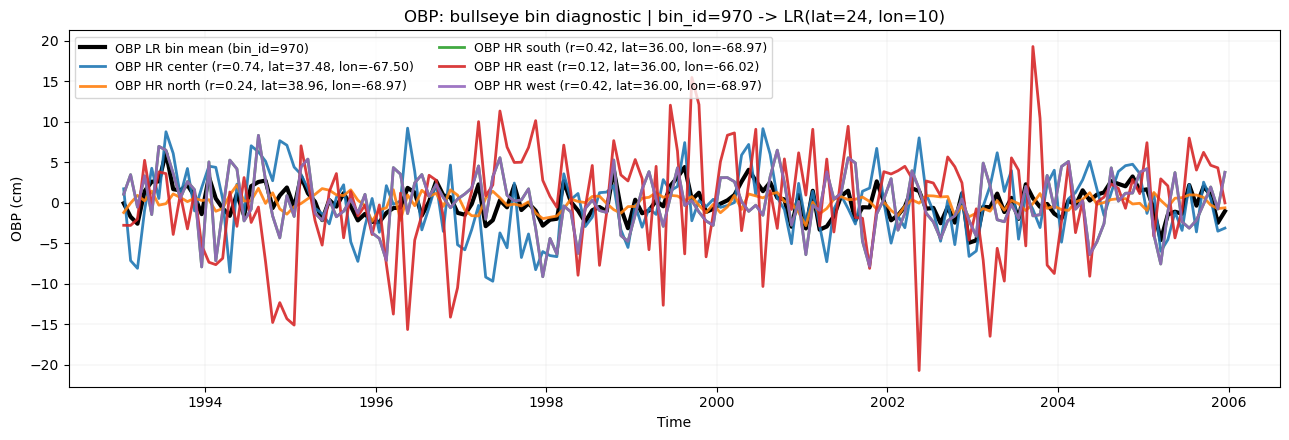

In [70]:
out = plot_bullseye_bin_timeseries(obp_hr, obp_lr, bin_id=970, time_slice=slice("1993","2005"))


In [93]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

def plot_bullseye_bin_timeseries_cor(
    obp_hr: xr.DataArray,
    obp_lr: xr.DataArray,
    bin_id: int,
    *,
    time_slice=None,          # e.g., slice("1998-01-01","2005-12-31")
    label="OBP",
    lw=2.0,
    print_corr=True,
):
    """
    For a given bin_id, plot:
      - LR bin time series (obp_lr at corresponding (ilat, ilon))
      - HR center pixel time series inside that bin
      - HR north/south/east/west edge pixel time series inside that bin

    Additionally prints corr(HR_pixel, LR_bin) for center + edges.
    """

    def corr_1d_nan(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        m = np.isfinite(x) & np.isfinite(y)
        n = int(m.sum())
        if n < 3:
            return np.nan, n
        x = x[m] - np.mean(x[m])
        y = y[m] - np.mean(y[m])
        denom = np.sqrt(np.sum(x * x) * np.sum(y * y))
        if denom == 0:
            return np.nan, n
        return float(np.sum(x * y) / denom), n

    # Map bin_id -> LR indices (bin_id = ilat*nlon + ilon)
    nlon_lr = obp_lr.sizes["lon"]
    ilat_lr = bin_id // nlon_lr
    ilon_lr = bin_id %  nlon_lr

    # Optional time subset
    if time_slice is not None:
        obp_hr_use = obp_hr.sel(time=time_slice)
        obp_lr_use = obp_lr.sel(time=time_slice)
    else:
        obp_hr_use = obp_hr
        obp_lr_use = obp_lr

    # LR series for that bin
    bin_ts = obp_lr_use.isel(lat=ilat_lr, lon=ilon_lr).compute()

    # Build mask for this bin (compute only this 2D boolean)
    mask2d = (obp_hr_use["bin_id"] == bin_id).compute()
    n_in = int(mask2d.sum().values)
    if n_in == 0:
        raise ValueError(f"No HR pixels found for bin_id={bin_id}. Check bin_id mapping.")

    # Indices of pixels in bin
    ij = np.argwhere(mask2d.values)
    ilat_idx = ij[:, 0]
    ilon_idx = ij[:, 1]

    lat_vals = obp_hr_use["lat"].values
    lon_vals = obp_hr_use["lon"].values
    lat_in = lat_vals[ilat_idx]
    lon_in = lon_vals[ilon_idx]

    # Center pixel: closest to centroid
    lat_c = float(np.nanmean(lat_in))
    lon_c = float(np.nanmean(lon_in))
    d2 = (lat_in - lat_c)**2 + (lon_in - lon_c)**2
    k_center = int(np.argmin(d2))

    # Edge pixels
    k_north = int(np.argmax(lat_in))
    k_south = int(np.argmin(lat_in))
    k_east  = int(np.argmax(lon_in))
    k_west  = int(np.argmin(lon_in))

    picks = {
        "center": (ilat_idx[k_center], ilon_idx[k_center]),
        "ne":  (ilat_idx[k_north],  ilon_idx[k_east]),
        "sw":  (ilat_idx[k_south],  ilon_idx[k_west]),
        "nw":   (ilat_idx[k_north],   ilon_idx[k_west]),
        "se":   (ilat_idx[k_south],   ilon_idx[k_east]),
    }

    # Extract HR time series
    hr_series = {}
    for name, (ii, jj) in picks.items():
        hr_series[name] = obp_hr_use.isel(lat=ii, lon=jj).compute()

    # ---- Compute correlations vs bin_ts
    corr_dict = {}
    x = bin_ts.values
    for name, ts in hr_series.items():
        r, n = corr_1d_nan(ts.values, x)
        corr_dict[name] = {"r": r, "n": n}

    if print_corr:
        print(f"\n{label} correlations with LR bin mean (bin_id={bin_id}, LR lat={ilat_lr}, lon={ilon_lr}):")
        for name in ["center", "ne", "sw", "nw", "se"]:
            r = corr_dict[name]["r"]
            n = corr_dict[name]["n"]
            print(f"  {name:6s}: r = {r: .3f} (n={n})")

    # ---- Plot
    fig, ax = plt.subplots(figsize=(13, 4.5))

    ax.plot(bin_ts["time"].values, bin_ts.values,
            label=f"{label} LR bin mean (bin_id={bin_id})", linewidth=3.0, color="k")

    for name, ts in hr_series.items():
        ii, jj = picks[name]
        r = corr_dict[name]["r"]
        ax.plot(
            ts["time"].values, ts.values,
            label=f"{label} HR {name} (r={r:.2f}, lat={float(lat_vals[ii]):.2f}, lon={float(lon_vals[jj]):.2f})",
            linewidth=lw, alpha=0.9
        )

    ax.set_title(f"{label}: bullseye bin diagnostic | bin_id={bin_id} -> LR(lat={ilat_lr}, lon={ilon_lr})")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{label} ({obp_hr.attrs.get('units','')})")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return {
        "bin_id": bin_id,
        "lr_index": (ilat_lr, ilon_lr),
        "hr_picks": picks,
        "n_pixels_in_bin": n_in,
        "corr_vs_bin": corr_dict,
    }


In [94]:
out = plot_bullseye_bin_timeseries(obp_hr, obp_lr, bin_id=975, time_slice=slice("1993","2005"))


KeyError: 'bin_id'


OBP correlations with LR bin mean (bin_id=975, LR lat=24, lon=15):
  center: r =  0.917 (n=156)
  ne    : r =  0.143 (n=156)
  sw    : r =  0.276 (n=156)
  nw    : r =  0.177 (n=156)
  se    : r =  0.114 (n=156)


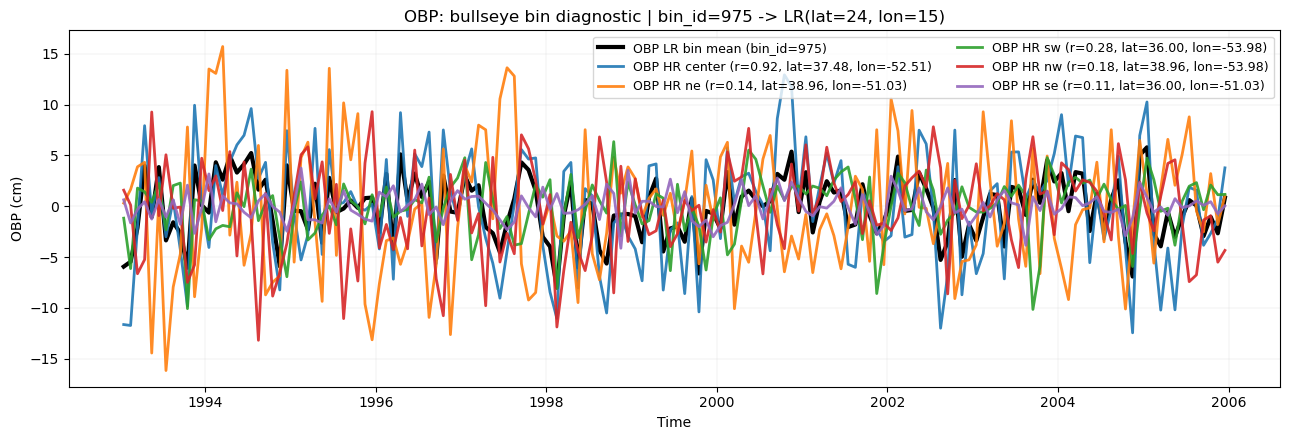

In [80]:
out = plot_bullseye_bin_timeseries_cor(obp_hr, obp_lr, bin_id=975, time_slice=slice("1993","2005"))



OBP correlations with LR bin mean (bin_id=970, LR lat=24, lon=10):
  center: r =  0.741 (n=156)
  ne    : r =  0.072 (n=156)
  sw    : r =  0.424 (n=156)
  nw    : r =  0.243 (n=156)
  se    : r =  0.117 (n=156)


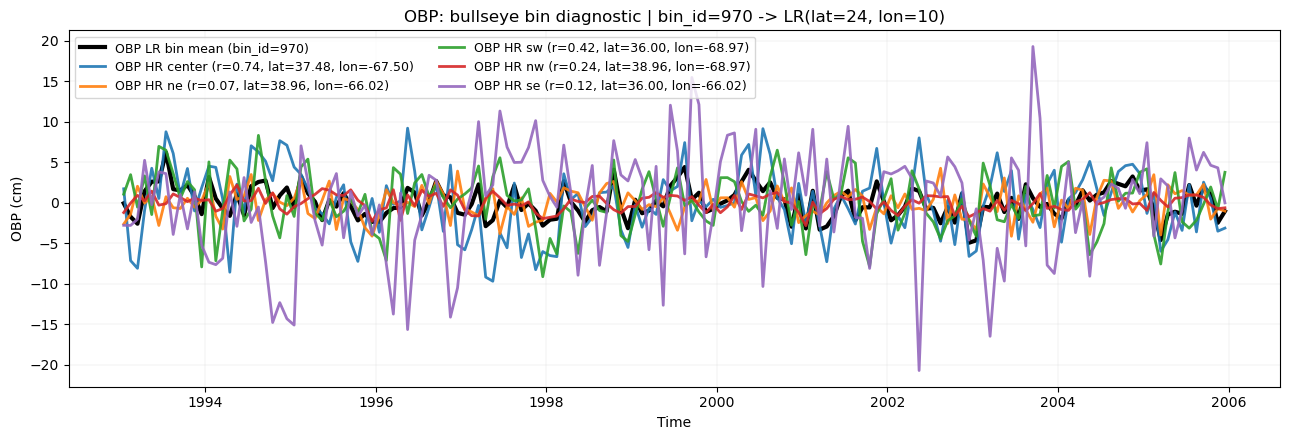

In [78]:
out = plot_bullseye_bin_timeseries_cor(obp_hr, obp_lr, bin_id=970, time_slice=slice("1993","2005"))


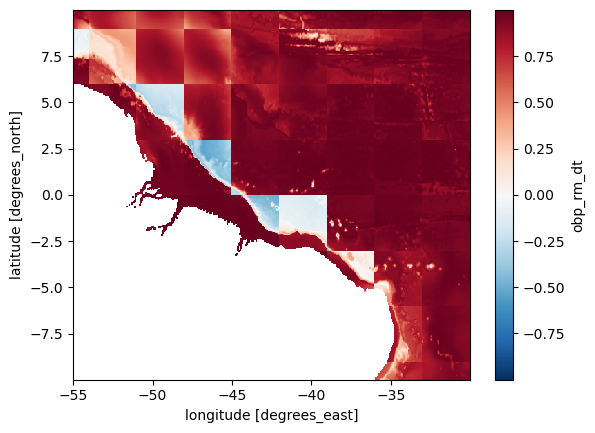

In [106]:
# Gulf Stream / Extension box (adjust as you like)
gs_extent = dict(lon=slice(-55, -30), lat=slice(-10, 10))

corr_gs = corr_3deg_c.sel(**gs_extent)

corr_gs.plot()

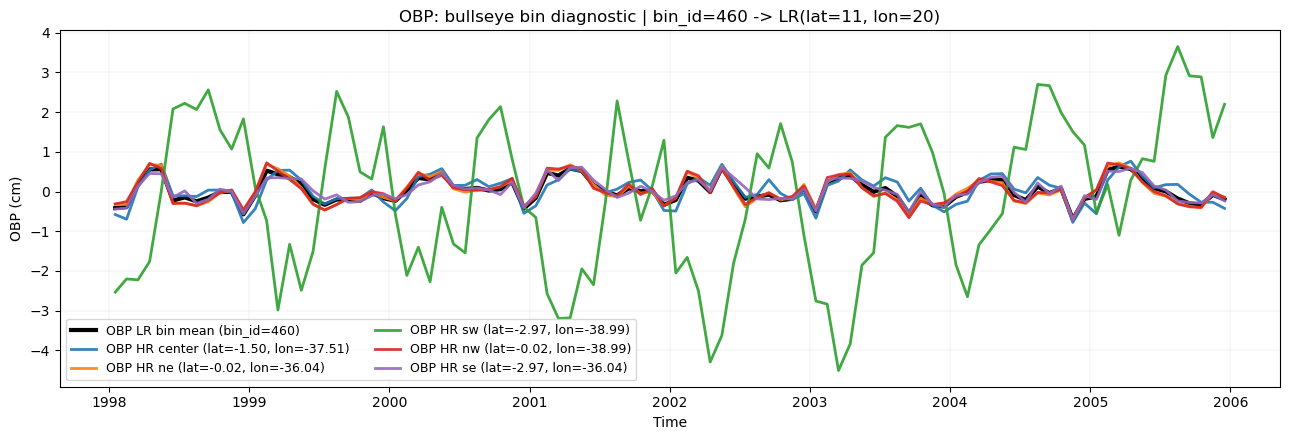

In [90]:
out = plot_bullseye_bin_timeseries(
    obp_hr=obp_hr,
    obp_lr=obp_lr,
    bin_id=460,  # <-- pick a bullseye bin_id from your map
    time_slice=slice("1998-01-01", "2005-12-31"),
    label="OBP"
)
#print(out)


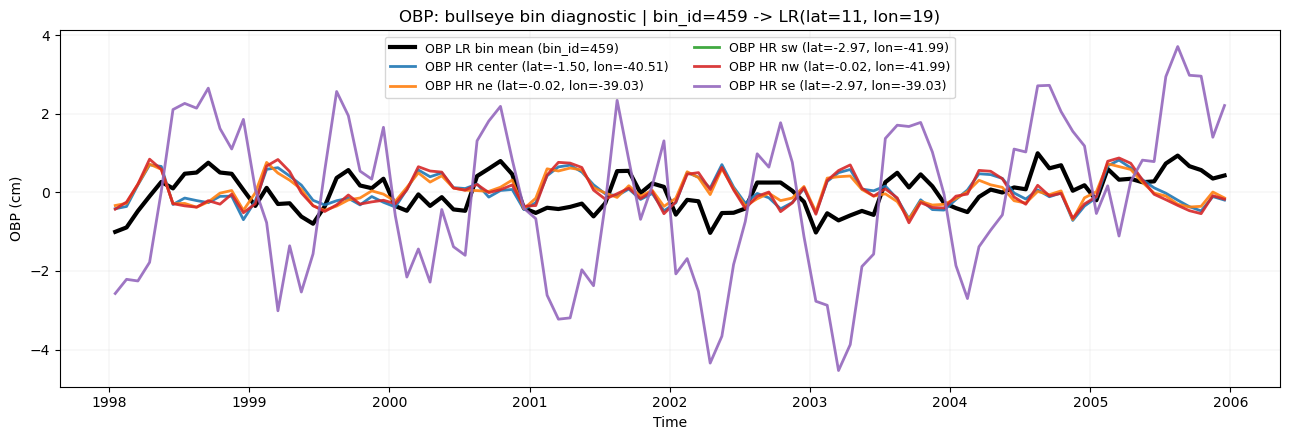

In [91]:
out = plot_bullseye_bin_timeseries(
    obp_hr=obp_hr,
    obp_lr=obp_lr,
    bin_id=459,  # <-- pick a bullseye bin_id from your map
    time_slice=slice("1998-01-01", "2005-12-31"),
    label="OBP"
)
#print(out)


In [24]:
obp_hr.sel(bin_id = 460)

KeyError: "no index found for coordinate 'bin_id'"

In [25]:
obp_hr

<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 2267, lon: 2715)>
dask.array<xarray-<this-array>, shape=(372, 2267, 2715), dtype=float32, chunksize=(372, 200, 200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99
    bin_id   (lat, lon) int64 0 0 0 0 0 0 0 ... 1359 1359 1359 1359 1359 1359
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm

In [33]:
temp = obp_hr["bin_id"] == 460

In [35]:
obp_hr.bin_id.isel(lat =11, lon =20)

<xarray.DataArray 'bin_id' ()>
array(0)
Coordinates:
    lon      float64 -97.09
    lat      float64 -33.0
    bin_id   int64 0

In [36]:
import numpy as np

# 2D boolean mask for this bin
mask_460 = (obp_hr["bin_id"] == 460)

# Indices where bin_id == 460
ij = np.argwhere(mask_460.values)    # shape (Npix, 2) -> (ilat_idx, ilon_idx)
ilat_idx = ij[:, 0]
ilon_idx = ij[:, 1]

# Convert to actual lat/lon values
lat_vals_hr = obp_hr["lat"].values[ilat_idx]
lon_vals_hr = obp_hr["lon"].values[ilon_idx]

print("Number of HR pixels in bin 460:", lat_vals_hr.size)
print("First few HR points in bin 460:")
for k in range(min(5, lat_vals_hr.size)):
    print(f"  lat={lat_vals_hr[k]:.3f}, lon={lon_vals_hr[k]:.3f}")


Number of HR pixels in bin 460: 4761
First few HR points in bin 460:
  lat=-2.974, lon=-38.991
  lat=-2.974, lon=-38.947
  lat=-2.974, lon=-38.904
  lat=-2.974, lon=-38.861
  lat=-2.974, lon=-38.817


In [79]:
import numpy as np

# 2D boolean mask for this bin
mask_460 = (obp_hr["bin_id"] == 460)

# Indices where bin_id == 460
ij = np.argwhere(mask_460.values)    # shape (Npix, 2) -> (ilat_idx, ilon_idx)
ilat_idx = ij[:, 0]
ilon_idx = ij[:, 1]

# Convert to actual lat/lon values
lat_vals_hr = obp_hr["lat"].values[ilat_idx]
lon_vals_hr = obp_hr["lon"].values[ilon_idx]

print("Number of HR pixels in bin 460:", lat_vals_hr.size)
print("First few HR points in bin 460:")
for k in range(min(5, lat_vals_hr.size)):
    print(f"  lat={lat_vals_hr[k]:.3f}, lon={lon_vals_hr[k]:.3f}")


Number of HR pixels in bin 460: 4761
First few HR points in bin 460:
  lat=-2.974, lon=-38.991
  lat=-2.974, lon=-38.947
  lat=-2.974, lon=-38.904
  lat=-2.974, lon=-38.861
  lat=-2.974, lon=-38.817


In [60]:
print(obp_hr)

<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 2267, lon: 2715)>
dask.array<xarray-<this-array>, shape=(372, 2267, 2715), dtype=float32, chunksize=(372, 200, 200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99
    bin_id   (lat, lon) int64 0 0 0 0 0 0 0 ... 1359 1359 1359 1359 1359 1359
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm


In [62]:
import numpy as np
import xarray as xr
import xesmf as xe

# -------------------------------------------
# 1. Define source and target grids
# -------------------------------------------
# Source: HR grid from obp_hr
ds_in = xr.Dataset(
    {
        "lat": (["lat"], obp_hr["lat"].values),
        "lon": (["lon"], obp_hr["lon"].values),
    }
)

# Target: 3° grid – use the existing LR grid if you already have it
# (this guarantees consistency with your previous 3° fields)
lat_3 = obp_lr["lat"].values   # e.g., -34.5 .. 64.5 step 3
lon_3 = obp_lr["lon"].values   # e.g., -97.5 .. 19.5 step 3

ds_out = xr.Dataset(
    {
        "lat": (["lat"], lat_3),
        "lon": (["lon"], lon_3),
    }
)

# -------------------------------------------
# 2. Build the regridder
# -------------------------------------------
# For true "bin-like" behavior you’d usually choose 'conservative';
# if you just want a smooth mapping, 'bilinear' is fine.
# Conservative requires cell bounds; bilinear does not, so start with that:

regridder = xe.Regridder(
    ds_in,
    ds_out,
    method="bilinear",           # or "conservative" if you set up bounds
    periodic=False,
    ignore_degenerate=True,      # useful with land/NaN
    reuse_weights=False,
)

# -------------------------------------------
# 3. Apply regridder to obp_hr (time, lat, lon)
# -------------------------------------------
obp_hr_3deg = regridder(obp_hr)   # dims: (time, lat_3, lon_3)
obp_hr_3deg = obp_hr_3deg.rename({"lat": "lat", "lon": "lon"})
obp_hr_3deg.name = "obp_rm_dt"

print(obp_hr_3deg)


<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<astype, shape=(372, 34, 40), dtype=float32, chunksize=(372, 34, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
Attributes:
    regrid_method:  bilinear


In [64]:
obp_hr_3deg_std = obp_hr_3deg.std(dim='time')

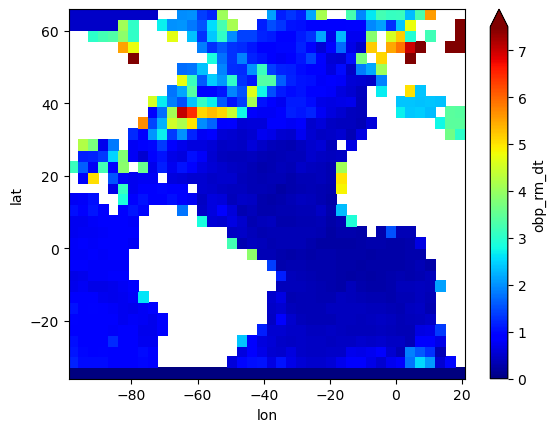

In [68]:
obp_hr_3deg_std.plot(cmap='jet', vmin = 0, vmax =7.5)

In [75]:
import numpy as np
import xarray as xr
import xesmf as xe

# -------------------------------------------
# 1. Define source and target grids
# -------------------------------------------
# Source: HR grid from obp_hr
ds_in = xr.Dataset(
    {
        "lat": (["lat"], obp_hr["lat"].values),
        "lon": (["lon"], obp_hr["lon"].values),
    }
)

# Target: 3° grid – use the existing LR grid if you already have it
# (this guarantees consistency with your previous 3° fields)
lat_3 = obp_lr["lat"].values   # e.g., -34.5 .. 64.5 step 3
lon_3 = obp_lr["lon"].values   # e.g., -97.5 .. 19.5 step 3

ds_out = xr.Dataset(
    {
        "lat": (["lat"], lat_3),
        "lon": (["lon"], lon_3),
    }
)

# -------------------------------------------
# 2. Build the regridder
# -------------------------------------------
# For true "bin-like" behavior you’d usually choose 'conservative';
# if you just want a smooth mapping, 'bilinear' is fine.
# Conservative requires cell bounds; bilinear does not, so start with that:

regridder = xe.Regridder(
    ds_in,
    ds_out,
    method="conservative",           # or "conservative" if you set up bounds
    periodic=False,
    ignore_degenerate=True,      # useful with land/NaN
    reuse_weights=False,
)

# -------------------------------------------
# 3. Apply regridder to obp_hr (time, lat, lon)
# -------------------------------------------
obp_hr_3deg = regridder(obp_hr)   # dims: (time, lat_3, lon_3)
obp_hr_3deg = obp_hr_3deg.rename({"lat": "lat", "lon": "lon"})
obp_hr_3deg.name = "obp_rm_dt"

print(obp_hr_3deg)


<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<astype, shape=(372, 34, 40), dtype=float32, chunksize=(372, 34, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
Attributes:
    regrid_method:  conservative


In [76]:
obp_hr_3deg_std = obp_hr_3deg.std(dim='time')

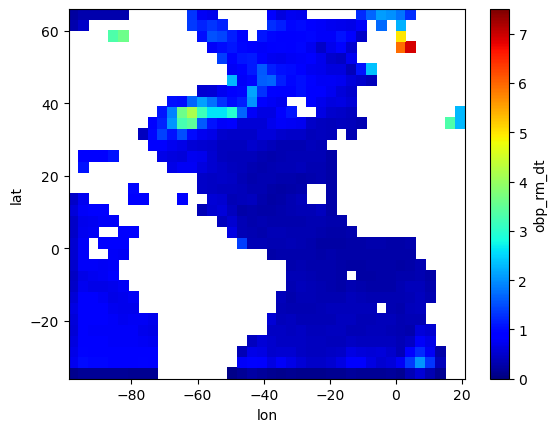

In [77]:
obp_hr_3deg_std.plot(cmap='jet', vmin = 0, vmax =7.5)

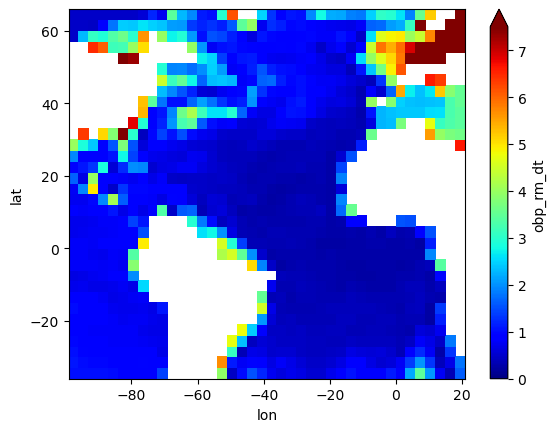

In [78]:
std_raw_3deg.plot(cmap='jet', vmin = 0, vmax =7.5)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

def plot_bin_timeseries(
    obp_hr: xr.DataArray,
    obp_lr: xr.DataArray,
    bin_id: int,
    *,
    time_slice=None,          # e.g., slice("1998-01-01","2005-12-31")
    label="OBP",
    lw=2.0,
):
    """
    For a given bin_id, plot:
      - LR bin time series (obp_lr at corresponding (ilat, ilon))
      - ALL HR pixel time series inside that bin (thin gray lines)
      - HR bin-mean time series (mean over all HR pixels in that bin)
      - Print std of LR bin-mean time series on the plot
    """

    # Map bin_id -> LR indices (must match your bin construction: bin_id = ilat*nlon + ilon)
    nlon_lr = obp_lr.sizes["lon"]
    ilat_lr = bin_id // nlon_lr
    ilon_lr = bin_id %  nlon_lr

    # Optional time subset
    if time_slice is not None:
        obp_hr_use = obp_hr.sel(time=time_slice)
        obp_lr_use = obp_lr.sel(time=time_slice)
    else:
        obp_hr_use = obp_hr
        obp_lr_use = obp_lr

    # LR series for that bin (this is your 3° bin-average time series)
    bin_ts = obp_lr_use.isel(lat=ilat_lr, lon=ilon_lr).compute()

    # Build mask for this bin (2D boolean on HR grid)
    mask2d = (obp_hr_use["bin_id"] == bin_id).compute()
    n_in = int(mask2d.sum().values)
    if n_in == 0:
        raise ValueError(f"No HR pixels found for bin_id={bin_id}. Check bin_id mapping.")

    # Stack HR pixels within this bin into a single "points" dimension
    # (time, lat, lon) -> (time, points)
    obp_hr_bin = obp_hr_use.where(mask2d)
    obp_hr_bin_stack = (
        obp_hr_bin
        .stack(points=("lat", "lon"))
        .dropna("points", how="all")
        .compute()
    )

    # HR bin-mean time series (mean over all HR points in bin)
    hr_bin_mean_ts = obp_hr_bin_stack.mean("points")

    # --- Compute std of bin-average time series (LR)
    std_lr_bin = float(bin_ts.std(dim="time"))
    units = obp_hr.attrs.get("units", "")

    # ---- Plot
    fig, ax = plt.subplots(figsize=(13, 4.5))

    # 1) Plot all HR pixel time series as light gray spaghetti
    for p in range(obp_hr_bin_stack.sizes["points"]):
        ts_p = obp_hr_bin_stack.isel(points=p)
        ax.plot(ts_p["time"].values,
                ts_p.values,
                color="lightgray",
                linewidth=0.4,
                alpha=0.5)

    # 2) Plot HR bin-mean (orange) and LR bin-mean (black)
    ax.plot(
        hr_bin_mean_ts["time"].values,
        hr_bin_mean_ts.values,
        label=f"{label} HR bin mean (all {n_in} px)",
        linewidth=2.0,
        color="tab:orange",
    )

    ax.plot(
        bin_ts["time"].values,
        bin_ts.values,
        label=f"{label} LR bin mean (bin_id={bin_id})",
        linewidth=1.0,
        color="k",
    )

    # Annotate std of LR bin-mean
    ax.text(
        0.02, 0.95,
        f"STD(LR bin mean) = {std_lr_bin:.3f} {units}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none"),
    )

    ax.set_title(
        f"{label}: bin time series | bin_id={bin_id} "
        f"(LR ilat={ilat_lr}, ilon={ilon_lr}, N_hr={n_in})"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{label} ({units})")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return {
        "bin_id": bin_id,
        "lr_index": (ilat_lr, ilon_lr),
        "n_pixels_in_bin": n_in,
        "std_lr_bin_mean": std_lr_bin,
        "hr_bin_mean_ts": hr_bin_mean_ts,
        "lr_bin_ts": bin_ts,
    }


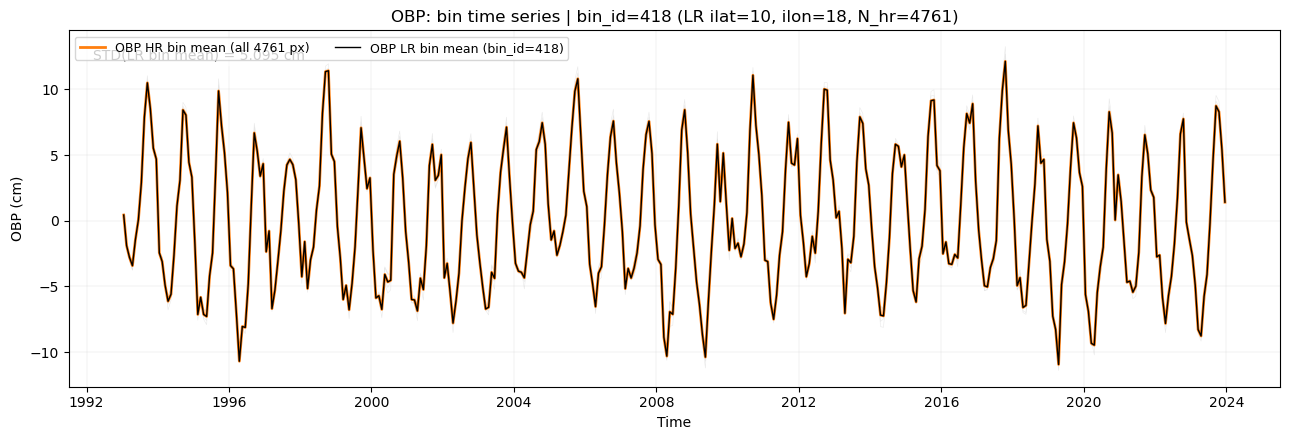

In [12]:
out = plot_bin_timeseries(
    obp_hr=obp_hr,
    obp_lr=obp_lr,
    bin_id=418,  # <-- pick a bullseye bin_id from your map
    time_slice=slice("1993-01-01", "2023-12-31"),
    label="OBP"
)
#print(out)


In [10]:
print(obp_lr,std_raw)

<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<rechunk-merge, shape=(372, 34, 40), dtype=float32, chunksize=(372, 34, 40), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm <xarray.DataArray 'obp_rm_dt' (lat: 2267, lon: 2715)>
array([[1.0432799 , 1.0456029 , 1.046008  , ...,        nan,        nan,
               nan],
       [1.0406827 , 1.0414099 , 1.0423471 , ...,        nan,        nan,
               nan],
       [1.0365763 , 1.0385385 , 1.0416696 , ...,        nan,        nan,
               nan],
       ...,
       [0.47244656, 0.47244656, 0.47244656, ..., 0.47244656, 0.47244656,
        0.47244656],

In [11]:
import numpy as np
import xarray as xr

def get_std_raw_in_bin(std_raw: xr.DataArray,
                       obp_lr: xr.DataArray,
                       bin_id: int) -> xr.DataArray:
    """
    Return all std_raw values that fall within the LR bin given by bin_id.

    Parameters
    ----------
    std_raw : xarray.DataArray
        High-resolution std field with dims (lat, lon).
    obp_lr : xarray.DataArray
        Low-resolution OBP field with dims (time, lat, lon) or (lat, lon).
    bin_id : int
        Linear bin index assuming row-major ordering:
        bin_id = ilat_lr * nlon_lr + ilon_lr.

    Returns
    -------
    std_bin : xarray.DataArray
        Subset of std_raw within the geographical extent of the LR bin.
    """

    # --- 1. Get LR grid info ---
    # If obp_lr has time dimension, drop it for coords
    if "time" in obp_lr.dims:
        lat_lr = obp_lr["lat"]
        lon_lr = obp_lr["lon"]
    else:
        lat_lr = obp_lr["lat"]
        lon_lr = obp_lr["lon"]

    nlat_lr = lat_lr.size
    nlon_lr = lon_lr.size

    # Decode bin_id -> (ilat_lr, ilon_lr)
    ilat_lr = bin_id // nlon_lr
    ilon_lr = bin_id %  nlon_lr

    # --- 2. Build LR cell edges (simple midpoint scheme) ---
    lat_vals = lat_lr.values
    lon_vals = lon_lr.values

    # latitude edges
    lat_edges = np.empty(nlat_lr + 1, dtype=float)
    lat_edges[1:-1] = 0.5 * (lat_vals[:-1] + lat_vals[1:])
    lat_edges[0]     = lat_vals[0]  - 0.5 * (lat_vals[1] - lat_vals[0])
    lat_edges[-1]    = lat_vals[-1] + 0.5 * (lat_vals[-1] - lat_vals[-2])

    # longitude edges
    lon_edges = np.empty(nlon_lr + 1, dtype=float)
    lon_edges[1:-1] = 0.5 * (lon_vals[:-1] + lon_vals[1:])
    lon_edges[0]     = lon_vals[0]  - 0.5 * (lon_vals[1] - lon_vals[0])
    lon_edges[-1]    = lon_vals[-1] + 0.5 * (lon_vals[-1] - lon_vals[-2])

    # Bounds for this bin
    lat_min = lat_edges[ilat_lr]
    lat_max = lat_edges[ilat_lr + 1]
    lon_min = lon_edges[ilon_lr]
    lon_max = lon_edges[ilon_lr + 1]

    # Ensure increasing order for slice
    if lat_min > lat_max:
        lat_min, lat_max = lat_max, lat_min
    if lon_min > lon_max:
        lon_min, lon_max = lon_max, lon_min

    # --- 3. Subset std_raw on HR grid within those bounds ---
    std_bin = std_raw.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )

    return std_bin


In [51]:
bin_id = 418  # whatever bin you care about
std_in_bin = get_std_raw_in_bin(std_raw, obp_lr, bin_id)

print(std_in_bin)
# If you want the raw numpy values:
std_vals = std_in_bin.values


<xarray.DataArray 'obp_rm_dt' (lat: 69, lon: 69)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon      (lon) float64 -44.99 -44.94 -44.9 -44.86 ... -42.12 -42.08 -42.03
  * lat      (lat) float64 -5.973 -5.929 -5.886 -5.842 ... -3.105 -3.061 -3.018


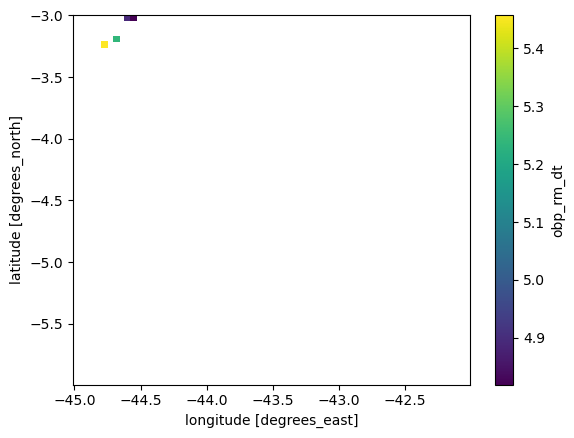

In [52]:
std_in_bin.plot()

(array([1., 1., 0., 0., 0., 0., 1., 0., 0., 1.]),
 array([4.819284 , 4.8831034, 4.9469223, 5.010741 , 5.0745606, 5.13838  ,
        5.202199 , 5.266018 , 5.3298373, 5.3936567, 5.4574757],
       dtype=float32),
 <BarContainer object of 10 artists>)

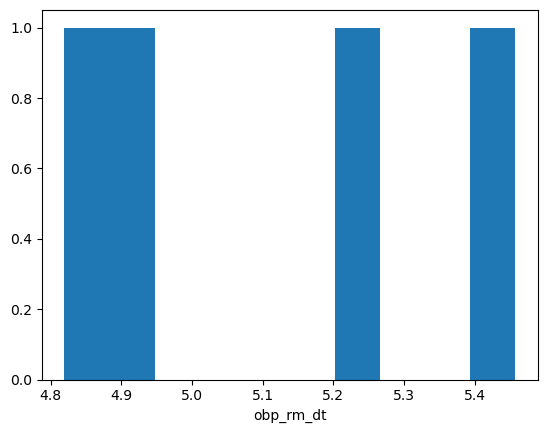

In [53]:
std_in_bin.plot.hist()

In [43]:
bin_id = 418  # whatever bin you care about
std_in_bin = get_std_raw_in_bin(std_raw_3deg, obp_lr, bin_id)

print(std_in_bin)
# If you want the raw numpy values:
std_vals = std_in_bin.values


<xarray.DataArray 'obp_rm_dt' (lat: 1, lon: 1)>
array([[5.095104]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -4.5
  * lon      (lon) float64 -43.5


In [44]:
std_in_bin

<xarray.DataArray 'obp_rm_dt' (lat: 1, lon: 1)>
array([[5.095104]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -4.5
  * lon      (lon) float64 -43.5

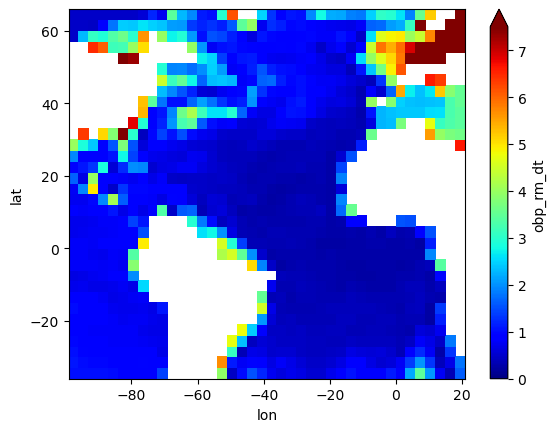

In [45]:
std_raw_3deg.plot(vmin =0, vmax =7.5, cmap='jet')

In [61]:
std_amazon = std_raw.sel(
    lat=slice(-5, 0),
    lon=slice(-48, -34)
)

std_amazon_3deg = std_raw_3deg.sel(
    lat=slice(-10, 10),
    lon=slice(-48, -34)
)



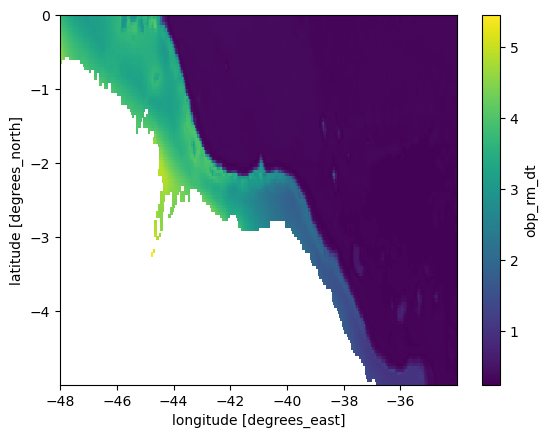

In [62]:
std_amazon.plot()

In [38]:
bin_id = 418  # whatever bin you care about
std_in_bin = get_std_raw_in_bin(std_amazon_3deg, obp_lr, bin_id)

print(std_in_bin)
# If you want the raw numpy values:
std_vals = std_in_bin.values


<xarray.DataArray 'obp_rm_dt' (lat: 1, lon: 1)>
array([[5.095104]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -4.5
  * lon      (lon) float64 -43.5


In [37]:
obp_lr

<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<rechunk-merge, shape=(372, 34, 40), dtype=float32, chunksize=(372, 34, 40), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm

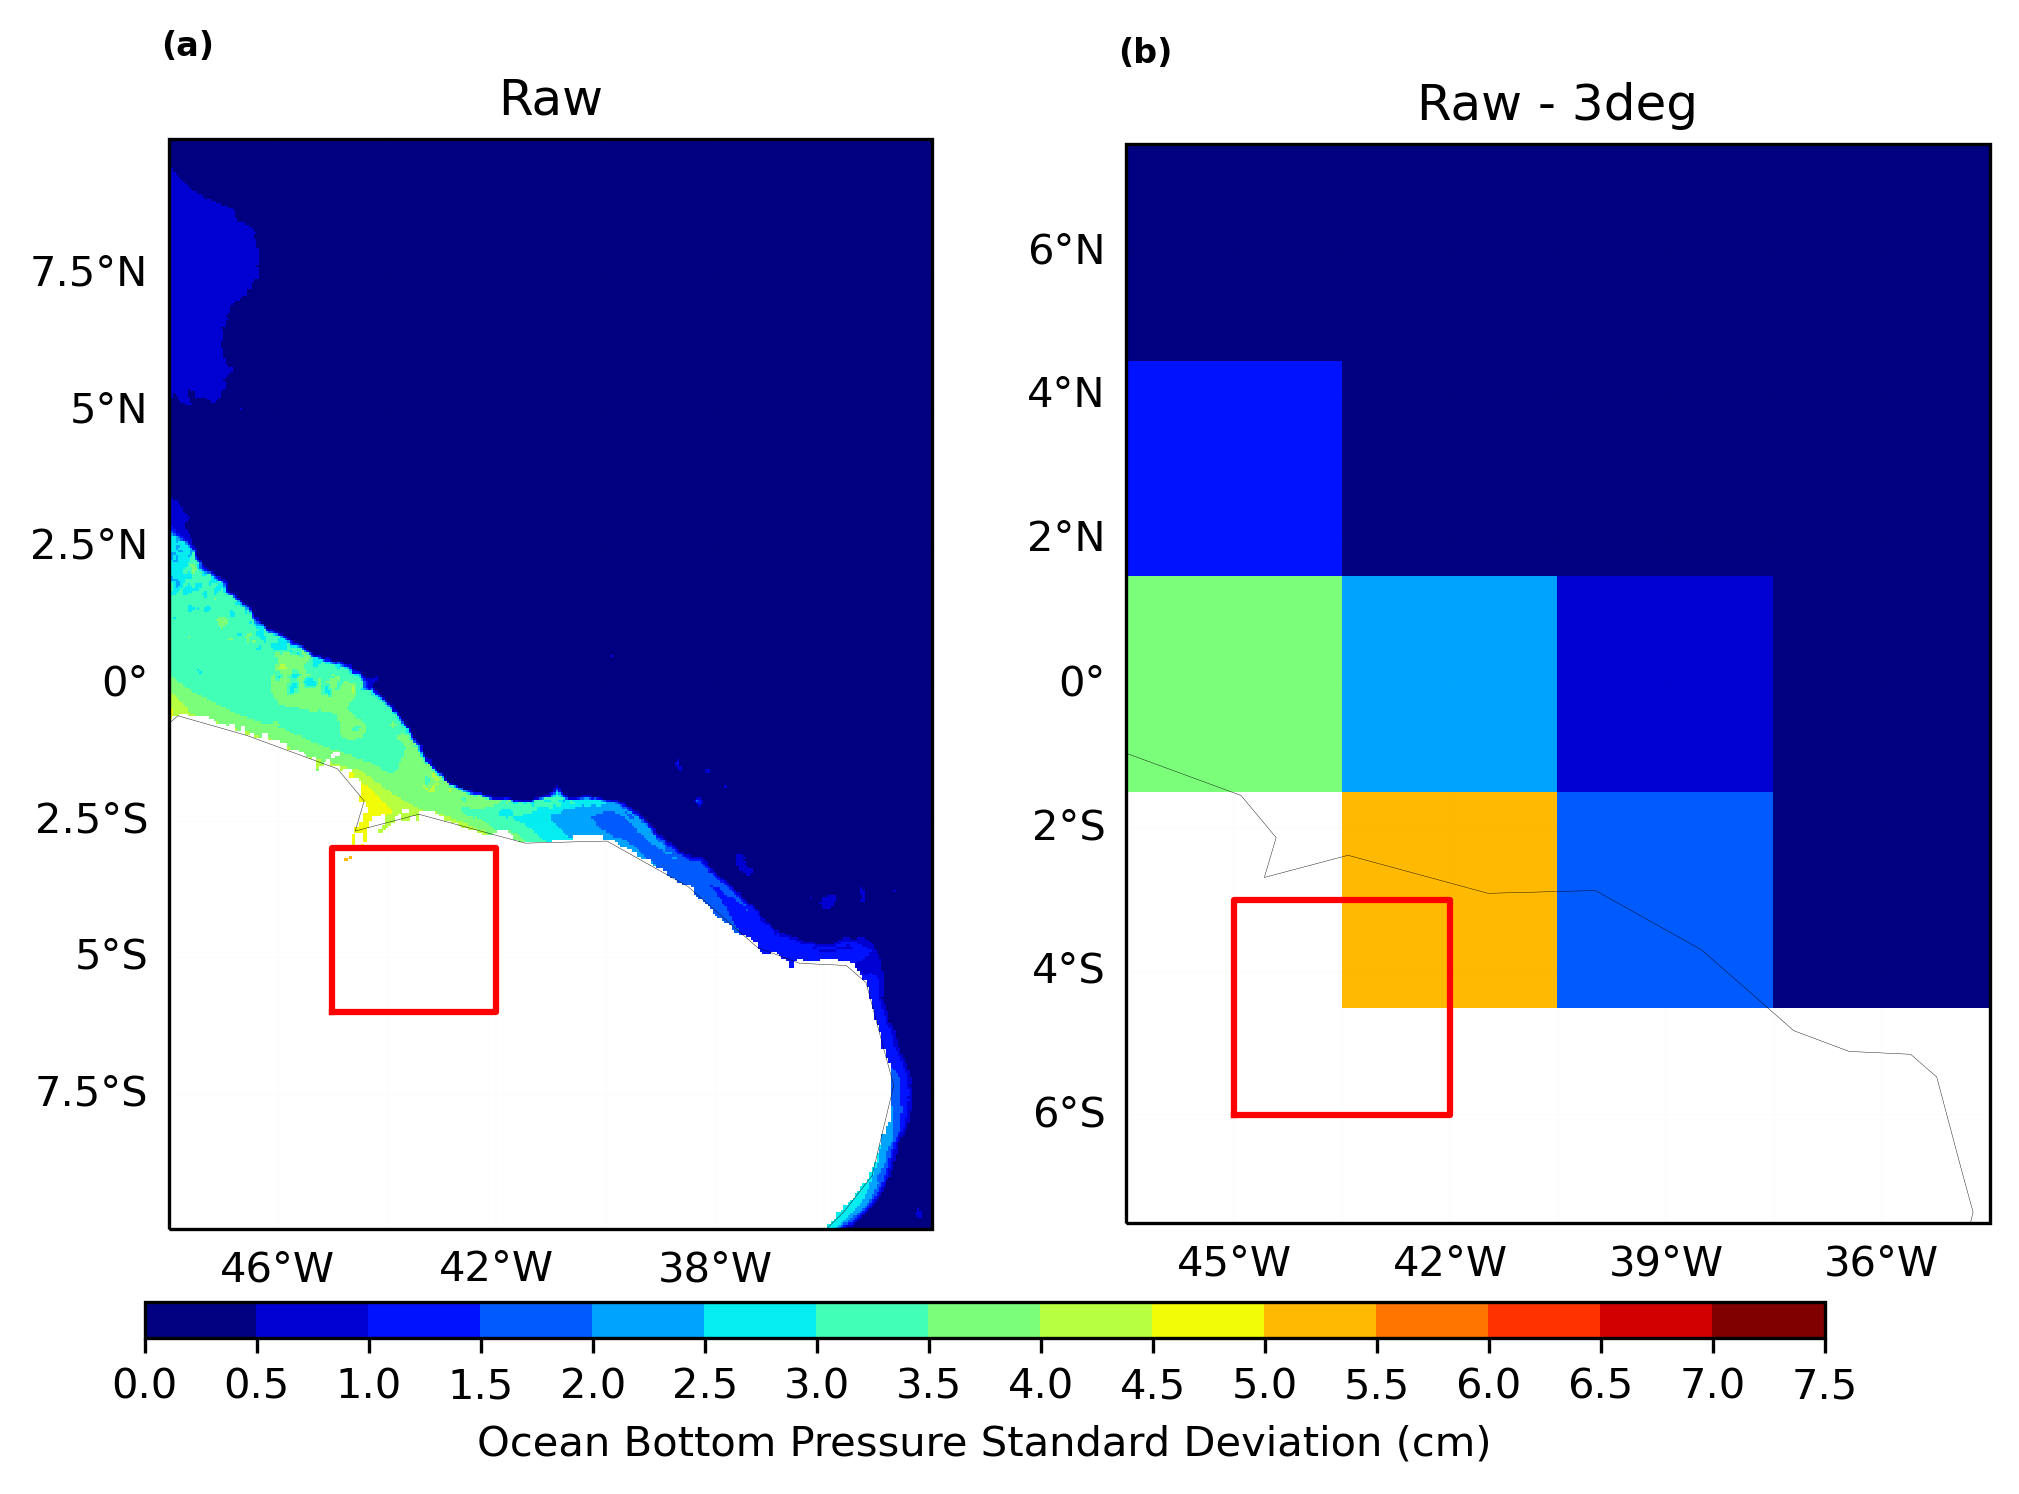

In [82]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_amazon,
    std_amazon_3deg
]

title_list = [
    "Raw", 
    "Raw - 3deg"
]

labels = ['(a)', '(b)']

# --- Colormap for std panels (0..8 by 0.5) ---
boundaries = np.arange(0, 8, 0.5)
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(7, 4.8), dpi=300,
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)}
)

# --- Box center and bounds (3° x 3°) ---
lat_c = -4.5
lon_c = -43.5
dlat = 3.0 / 2.0
dlon = 3.0 / 2.0

lat_min = lat_c - dlat   # -6.0
lat_max = lat_c + dlat   # -3.0
lon_min = lon_c - dlon   # -45.0
lon_max = lon_c + dlon   # -42.0

box_lons = [lon_min, lon_max, lon_max, lon_min, lon_min]
box_lats = [lat_min, lat_min, lat_max, lat_max, lat_min]

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(
        data.lon,
        data.lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i <= 3
    gl.ylabels_left = True
    gl.right_labels = False
    gl.top_labels = False

    # Land feature
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='black',
        facecolor='none',
        linewidth=0.1
    )
    ax.add_feature(land, alpha=1)

    # --- DRAW RED 3°x3° BOX ---
    ax.plot(
        box_lons,
        box_lats,
        transform=ccrs.PlateCarree(),
        color='red',
        linewidth=1.5
    )

    ax.set_title(title, fontsize=12)

    # Subplot labels (a), (b)
    ax.text(
        -0.01, 1.1, labels[i], transform=ax.transAxes,
        fontsize=8, fontweight='bold', va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6)
    )

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


In [87]:
data_lr = std_raw_3deg  # (lat, lon) from bin_average_ll_true2d

lat_c = data_lr["lat"].values   # centers, e.g. [..., -7.5, -4.5, -1.5, ...]
lon_c = data_lr["lon"].values   # centers, e.g. [..., -46.5, -43.5, -40.5, ...]

dlat = float(lat_c[1] - lat_c[0])   # should be ~3.0
dlon = float(lon_c[1] - lon_c[0])   # should be ~3.0

import numpy as np

# latitude edges (length Nlat+1)
lat_edges = np.empty(lat_c.size + 1, dtype=float)
lat_edges[1:-1] = 0.5 * (lat_c[:-1] + lat_c[1:])
lat_edges[0]    = lat_c[0]  - 0.5 * dlat
lat_edges[-1]   = lat_c[-1] + 0.5 * dlat

# longitude edges (length Nlon+1)
lon_edges = np.empty(lon_c.size + 1, dtype=float)
lon_edges[1:-1] = 0.5 * (lon_c[:-1] + lon_c[1:])
lon_edges[0]    = lon_c[0]  - 0.5 * dlon
lon_edges[-1]   = lon_c[-1] + 0.5 * dlon



In [84]:
std_raw_3deg

<xarray.DataArray 'obp_rm_dt' (lat: 34, lon: 40)>
array([[ 1.0315744 ,  1.0440849 ,  1.039411  , ...,  0.78087884,
         0.36398697,  1.628216  ],
       [ 1.1105589 ,  1.0096748 ,  0.9950938 , ...,  0.3847829 ,
         0.6954107 ,  1.8080525 ],
       [ 1.0391994 ,  0.9658484 ,  0.91835594, ...,  0.27919185,
         1.3274251 ,         nan],
       ...,
       [ 0.47244653,  2.297817  ,  3.0964785 , ...,  9.113085  ,
        13.349753  , 13.611187  ],
       [ 0.47244653,  0.47244656,  0.44250393, ...,         nan,
        13.368525  , 13.317572  ],
       [ 0.47244653,  0.47244653,  0.47244653, ...,         nan,
                nan, 11.839288  ]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5

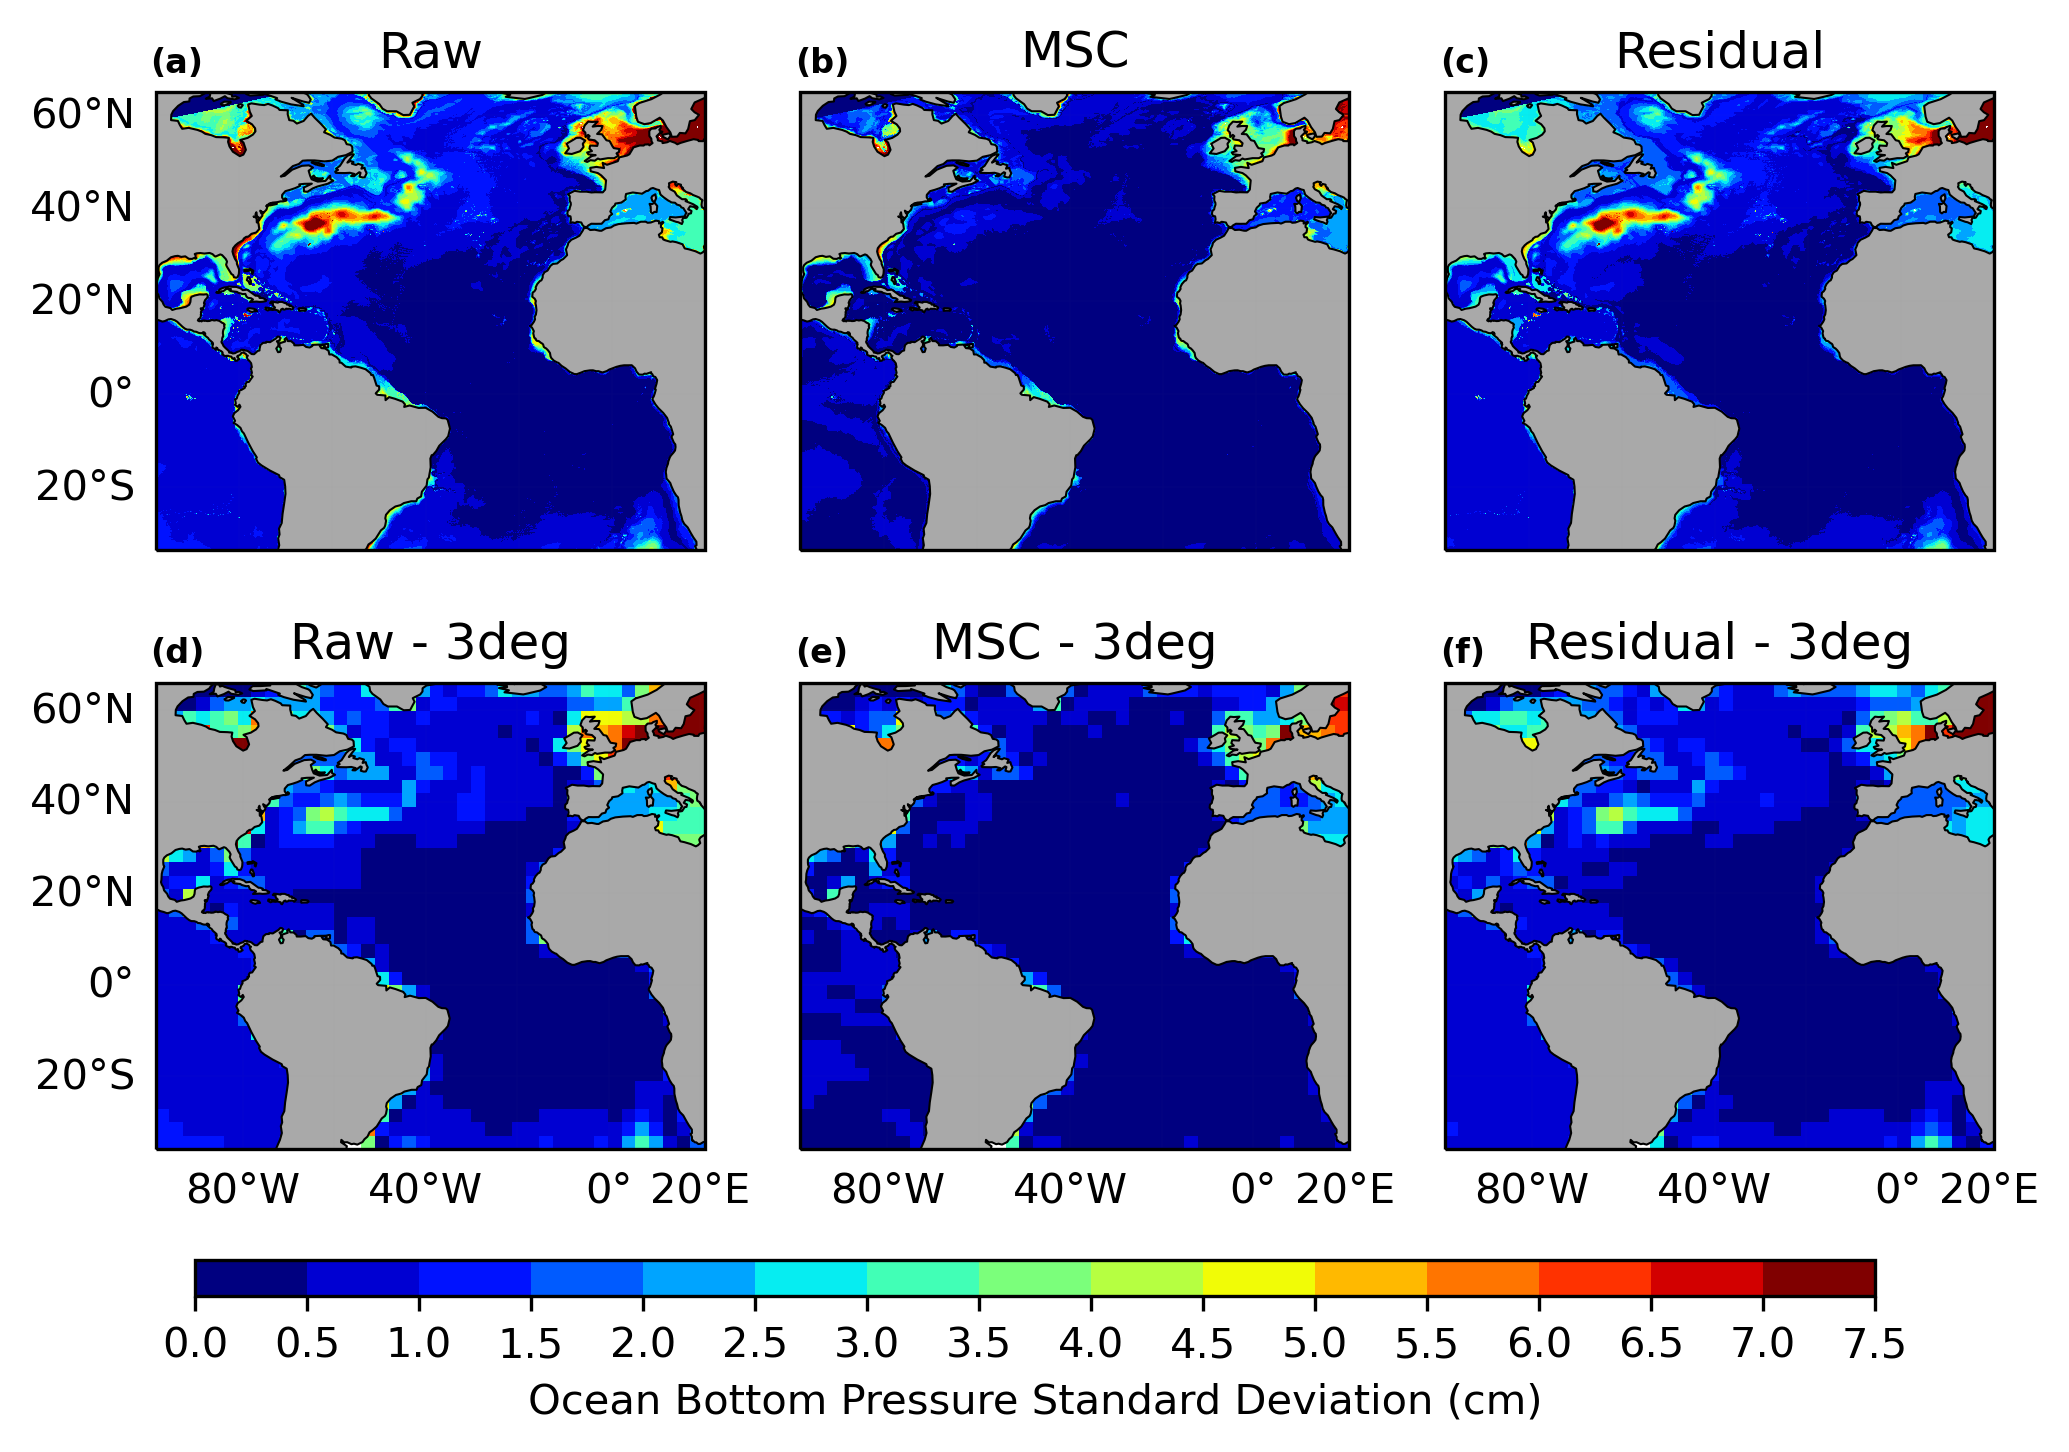

In [93]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    if i in (0, 1, 2):
        pc = ax.pcolormesh(data.lon, 
                           data.lat, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    else:
        pc = ax.pcolormesh(lon_edges, 
                           lat_edges, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black', facecolor='darkgray'
    ))
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
#plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM.png", dpi=500, bbox_inches='tight')

plt.show()


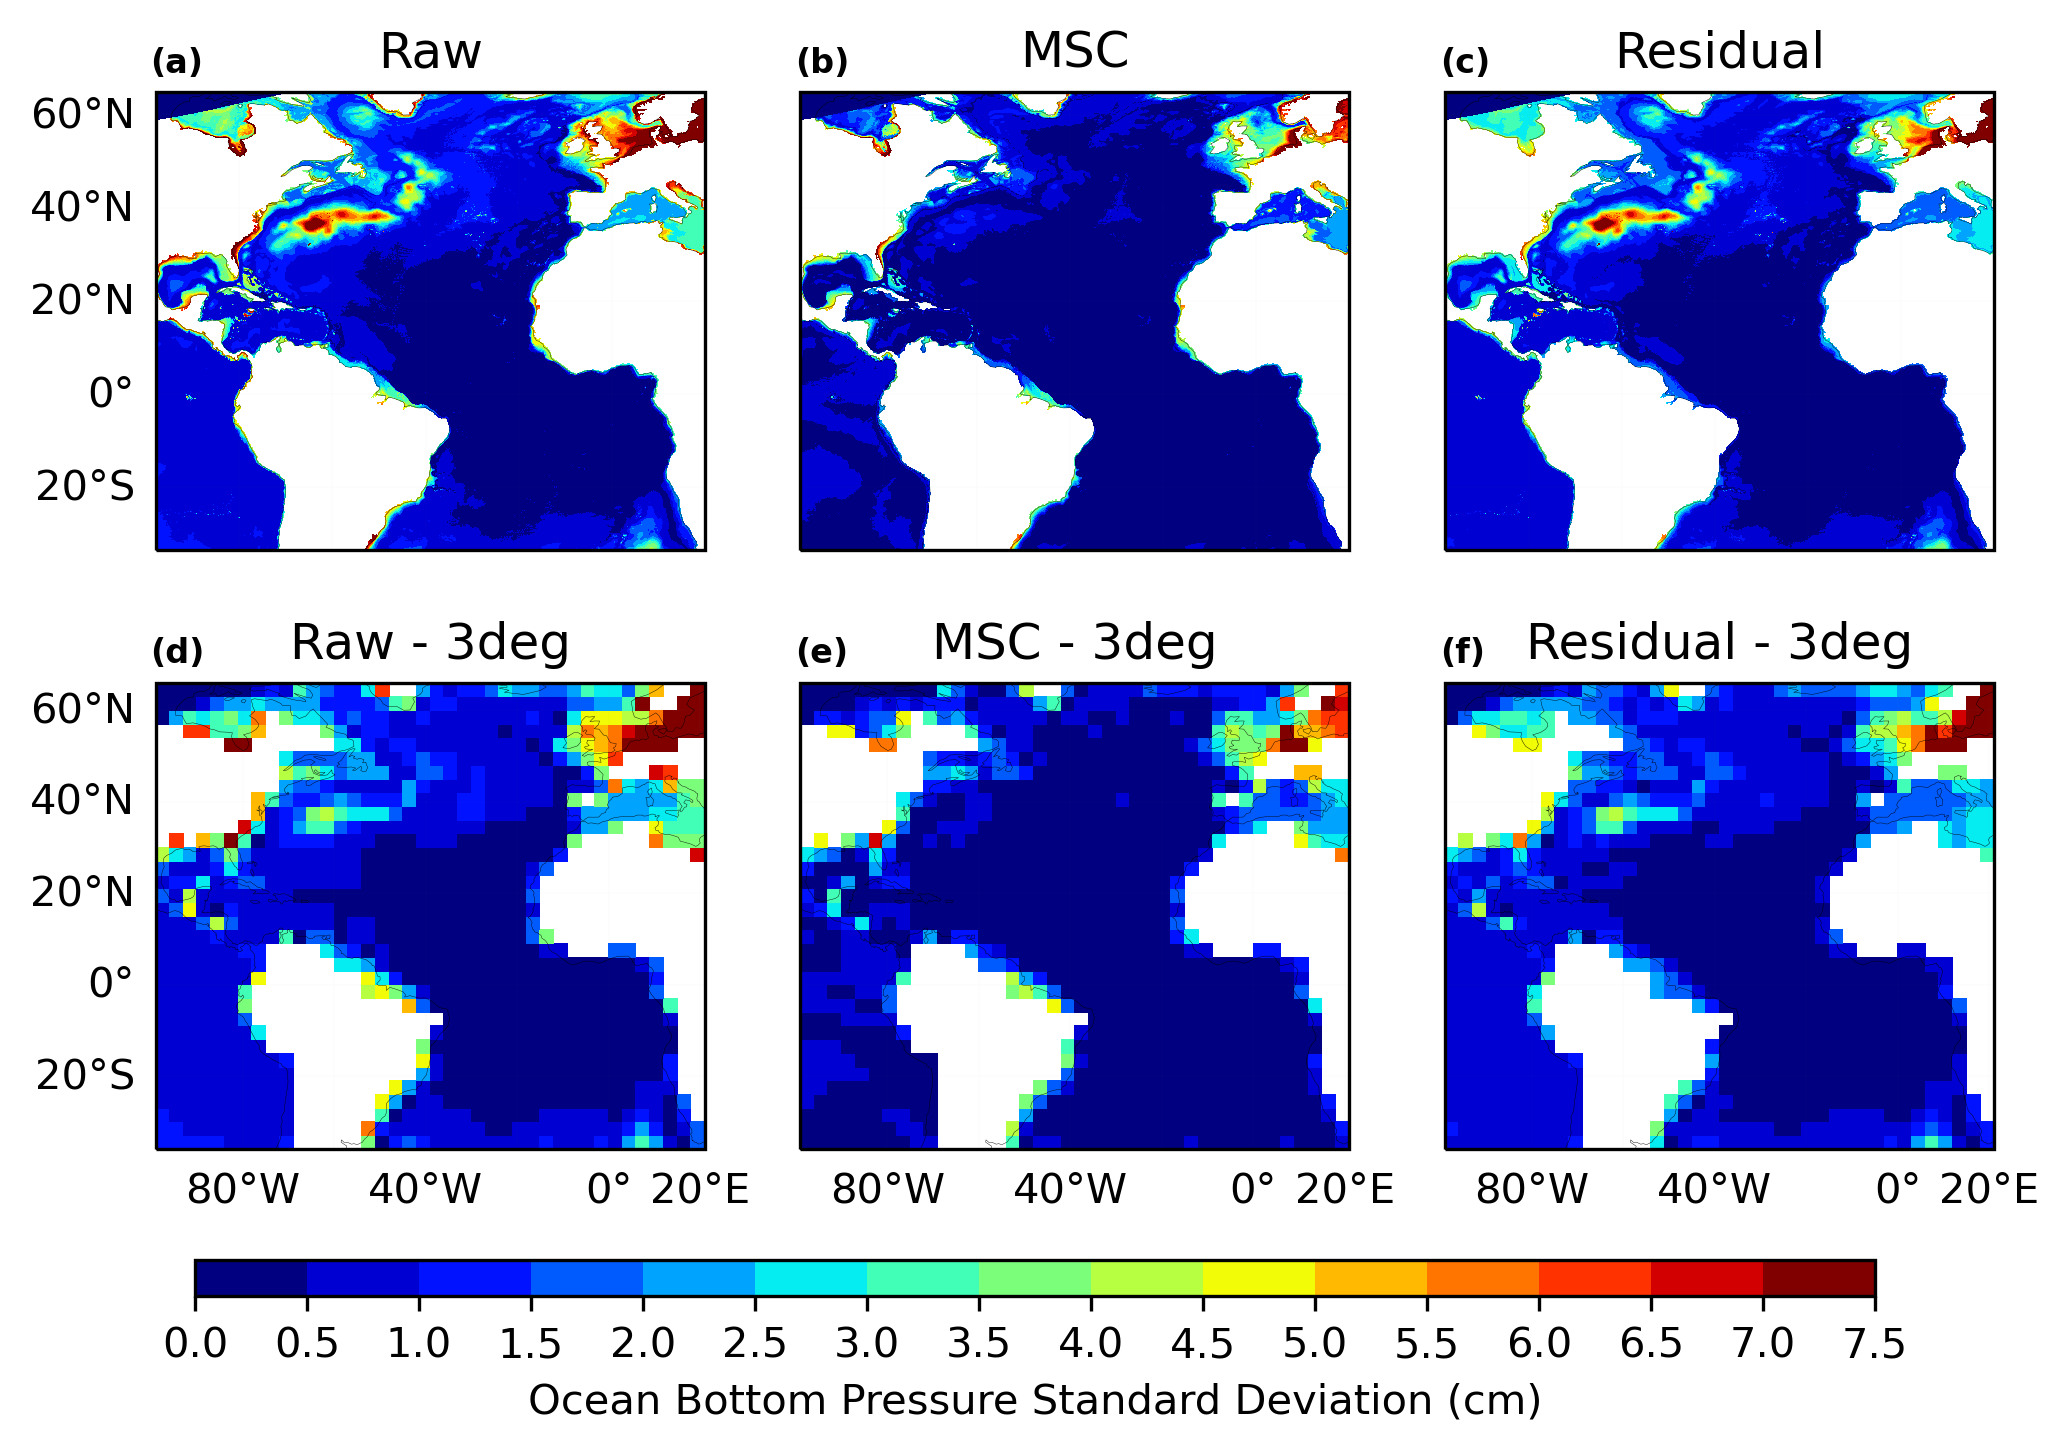

In [95]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    if i in (0, 1, 2):
        pc = ax.pcolormesh(data.lon, 
                           data.lat, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    else:
        pc = ax.pcolormesh(lon_edges, 
                           lat_edges, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    # Land feature
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='black',
        facecolor='none',
        linewidth=0.1
    )
    ax.add_feature(land, alpha=1)
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
#plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM.png", dpi=500, bbox_inches='tight')

plt.show()


In [90]:
lon_edges

array([-99., -96., -93., -90., -87., -84., -81., -78., -75., -72., -69.,
       -66., -63., -60., -57., -54., -51., -48., -45., -42., -39., -36.,
       -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,  -6.,  -3.,
         0.,   3.,   6.,   9.,  12.,  15.,  18.,  21.])

In [91]:
lat_edges

array([-36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,  -6.,
        -3.,   0.,   3.,   6.,   9.,  12.,  15.,  18.,  21.,  24.,  27.,
        30.,  33.,  36.,  39.,  42.,  45.,  48.,  51.,  54.,  57.,  60.,
        63.,  66.])

In [92]:
std_raw_3deg

<xarray.DataArray 'obp_rm_dt' (lat: 34, lon: 40)>
array([[ 1.0315744 ,  1.0440849 ,  1.039411  , ...,  0.78087884,
         0.36398697,  1.628216  ],
       [ 1.1105589 ,  1.0096748 ,  0.9950938 , ...,  0.3847829 ,
         0.6954107 ,  1.8080525 ],
       [ 1.0391994 ,  0.9658484 ,  0.91835594, ...,  0.27919185,
         1.3274251 ,         nan],
       ...,
       [ 0.47244653,  2.297817  ,  3.0964785 , ...,  9.113085  ,
        13.349753  , 13.611187  ],
       [ 0.47244653,  0.47244656,  0.44250393, ...,         nan,
        13.368525  , 13.317572  ],
       [ 0.47244653,  0.47244653,  0.47244653, ...,         nan,
                nan, 11.839288  ]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5